In [1]:
# Pruebas de conexiones a BQ y MySql local (def)

from google.cloud import bigquery
from google.oauth2 import service_account
from google.colab import auth
auth.authenticate_user()
client = bigquery.Client(project='sprint3-analytics-cristina-f-t')



ModuleNotFoundError: No module named 'google.cloud'

In [ ]:
sql_query = """select * from sprint3_gold.product_sales_ranking"""
query_results = client.query(sql_query).result().to_dataframe()

In [ ]:
display(query_results)

Ejecutar en la terminal local para inicializar el servicio, debe mantenerse activo mientras se use:  


py -m notebook --no-browser --NotebookApp.allow_origin="https://colab.research.google.com" --NotebookApp.allow_credentials=True --port=8888 --NotebookApp.port_retries=0

- Esta linea cambia a cada ejecucion del codigo superior, y se debe actualizar en la conexion a local de colab:  
http://127.0.0.1:8888/tree?token=bf9ca177ad035dc1982227b13034902b22af627c78dfec32

In [2]:
import os
import socket
import sys

print("Equip:", socket.gethostname())
print("Python:", sys.executable)
print("Usuari:", os.getenv("Kris") or os.getenv("Kris"))

Equip: ChuwiKris
Python: C:\Python314\python.exe
Usuari: None


In [ ]:
from sqlalchemy import create_engine
import pandas as pd

# 1. Define tus credenciales
USER = "xxxx"
PASSWORD = "xxxx"
HOST = "127.0.0.1"
PORT = "3306"
DATABASE = "sales"

# 2. Crea la URI con el formato correcto para SQLAlchemy + PyMySQL
#DATABASE_URI = f"mysql+pymysql://{USER}:{PASSWORD}@{HOST}:{PORT}/{DATABASE}"
DATABASE_URI = f"mysql+pymysql://{USER}:{PASSWORD}@{HOST}/{DATABASE}"
# Crear el motor de conexión
engine = create_engine(DATABASE_URI)
# Ejecutar la consulta pasando el 'engine' en lugar de la conexión antigua
query = "SELECT * FROM transactions;"
df_transactions = pd.read_sql(query, con=engine)

# Test: Ver la cabecera
df_transactions.head()

,id,card_id,business_id,timestamp,amount,declined,product_ids,user_id,lat,longitude,discount_amount,tax_amount,shipping_amount,channel,campaign_id,device_type,is_international,decline_reason,distance_km
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,CcS-9294,b-2458,2024-08-28 07:16:46,433.51,0,"16, 26, 97, 87",4713,46.19992926158272,1.4355402821327607,34.17,72.25,0.00,online,SUMMER_TRAVEL,mobile,0,,59.95
1,000447FE-B650-4DCF-85DE-C7ED0EE1CAAD,CcS-5019,b-2370,2016-12-21 20:07:18,172.56,0,"66, 69, 87",438,41.59720554463741,12.22175994259365,19.92,29.86,6.99,online,CHRISTMAS_PEAK,tablet,0,,494.51
2,00045D6B-ED2E-4F2F-8186-CEE074D875D0,CcS-6699,b-2390,2020-07-14 15:37:45,332.38,0,"30, 11, 16, 81",2118,29.757295899964348,-95.37963676492454,16.10,22.47,0.00,store,SUMMER_TRAVEL,pos,1,,1157.10
3,000481C3-1C26-4FEF-83A0-4CD0EB004BBD,CcS-6696,b-2230,2017-09-04 19:44:53,175.00,0,72,2115,53.54888376797025,-113.50305274646564,1.05,14.45,0.00,store,NO_CAMPAIGN,pos,0,,540.32
4,00051AA4-9CBE-4268-B070-C38062A1B3E2,CcS-7606,b-2266,2017-01-05 18:19:25,158.55,0,18,3025,52.20836951654172,5.690806474241335,25.31,25.96,8.99,marketplace,WINTER_SALE,desktop,0,,28.52


# Nivell 1 - Visualització analítica guiada en Python

L'objectiu del nivell és aplicar criteri analític per responderé preguntes de negoci mitjançant visualitzacions en Python, treballant amb les taules del model del Sprint 2 a partir de l’exercici 8, carregades com a DataFrame independents.

En aquest nivell no es demana construir un dataset final ni unificar totes les taules, sinó:

» Identificar quina informació és necessària.

» Escollir correctament la taula (o taules) rellevant(s).

» Construir visualitzacions adequades.

» Interpretar els resultats obtinguts.

Aquest nivell posa l'èmfasi en pensar abans de programar.

# Cargamos las tablas como dataframes independientes

In [4]:
# La tabla Transactions aunque ya la tenemos cargada
query = "SELECT * FROM transactions;"
df_transactions = pd.read_sql(query, con=engine)
# Tabla companies
query = "SELECT * FROM companies;"
df_companies = pd.read_sql(query, con=engine)
# Tabla credit_cards
query = "SELECT * FROM credit_cards;"
df_credit_cards = pd.read_sql(query, con=engine)
# Tabla users
query = "SELECT * FROM users;"
df_users = pd.read_sql(query, con=engine)
# Tabla products
query = "SELECT * FROM products;"
df_products = pd.read_sql(query, con=engine)

## Exercici 1: Preguntes analítiques directes (sense integracions complexes)
🌍 Context: Es treballa amb una sola taula a la vegada, escollida segons la pregunta analítica. No cal fer merge entre taules ni definir funcions avançades.

+ Aspectes a revisar i analitzar:

» Identificar quina informació és necessària

Quin DataFrame és el més adequat per respondre la pregunta.

» Escollir correctament la taula (o taules) rellevant(s).

» Tipus de variables implicades.

» Elecció del tipus de gràfic.

Preguntes analítiques: (només utilitzant la taula de transaccions) :

### 1.1 Com evoluciona el nombre de transaccions al llarg del temps? Exemple de passos guiats amb pandas.

Selecciona la columna temporal adequada.  
Defineix el nivell temporal d'anàlisi.

Compta el nombre de registres per període temporal.  
Ordena els resultats cronològicament.  
Visualitza l'evolució amb un gràfic de línies amb pandas.  

- Per a cada pregunta: Construeix una visualització senzilla en Python sense utilitzar IA.
- Interpreta breument el resultat obtingut.
- Utilitza les eines d'IA disponibles a Colab per proposar una visualització alternativa.
- Compara el resultat inicial amb el resultat proposat per la IA i valora críticament si la nova proposta és una millora o un empitjorament, justificant la teva decisió.

In [5]:
# Elegimos la tabla/df de transacciones

# Nos aseguramos que el campo sea 'datetime'
df_transactions['timestamp'] = pd.to_datetime(df_transactions['timestamp'])

# Agrupamos por mes y contamos en número de transacciones
transaccions_mensuals = df_transactions.groupby(df_transactions['timestamp'].dt.to_period('M')).size()
# display("Transaccions mensuals", transaccions_mensuals)


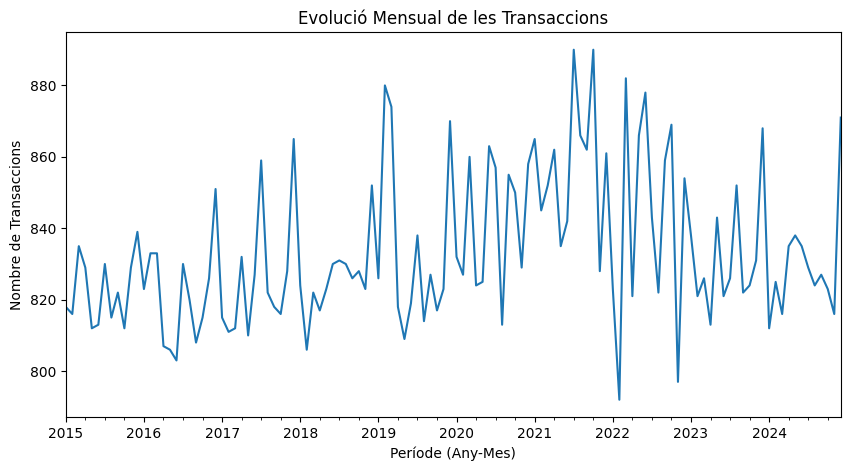

In [8]:
import matplotlib.pyplot as plt

# Ordenamos los resultados cronológicamente (Paso explícito)
transaccions_mensuals = transaccions_mensuals.sort_index()

# Dibujamos el gráfico de líneas de Pandas
transaccions_mensuals.plot(kind='line', figsize=(10, 5), title="Evolució Mensual de les Transaccions")
plt.xlabel("Període (Any-Mes)")
plt.ylabel("Nombre de Transaccions")
plt.show()

#### Interpretación

* **Estabilidad operativa:** El volumen mensual oscila de manera muy estable entre **~790 y ~890 transacciones mensuales** a lo largo de los 10 años, sin mostrar una tendencia estructural claramente ascendente o descendente a largo plazo.

#### Resultado propuesto por la IA :


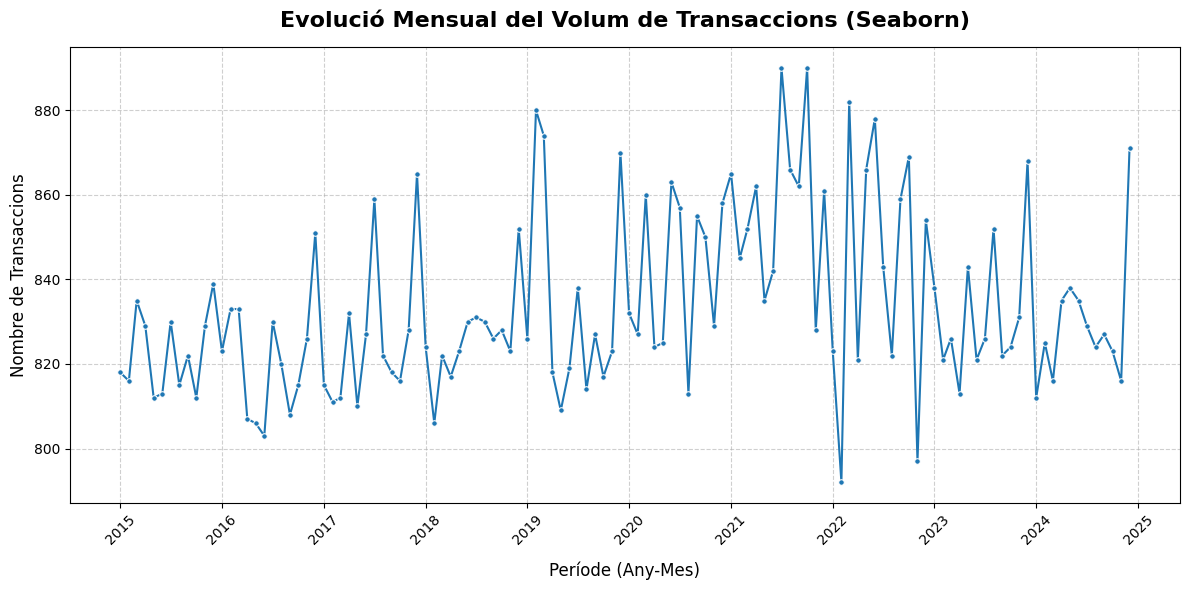

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# Convert the Series to a DataFrame for easier plotting with seaborn
df_monthly_transactions = transaccions_mensuals.reset_index()
df_monthly_transactions.columns = ['Month', 'Transactions']

# Convert 'Month' back to datetime for proper x-axis scaling in seaborn
df_monthly_transactions['Month'] = pd.to_datetime(df_monthly_transactions['Month'].astype(str))

plt.figure(figsize=(12, 6))
sns.lineplot(x='Month', y='Transactions', data=df_monthly_transactions, marker='o', markersize=4, color='#1f77b4')

plt.title('Evolució Mensual del Volum de Transaccions (Seaborn)', fontsize=16, pad=15, fontweight='bold')
plt.xlabel('Període (Any-Mes)', fontsize=12, labelpad=10)
plt.ylabel('Nombre de Transaccions', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Improve x-axis date formatting
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Vemos que la IA ha elegido igualmente un gráfico de líneas

---

#### Valoración Crítica de la Propuesta de la IA

---

### Lo Positivo *(Puntos a favor)*

* **Eje X más limpio:** En lugar de recargar el gráfico mostrando cada mes y año (*2015-01*), Seaborn/Matplotlib simplifica la escala dejando solo los años (*2015, 2016, 2017...*). Esto evita que el texto se solape y facilita la lectura.

---

### Puntos a Mejorar *(Limitaciones)*

* **Falta de valor analítico extra:** Para ser una alternativa, no aporta información realmente nueva. Habría estado bien incluir una media móvil (*para suavizar los picos*) o una descomposición estacional (*para comparar los meses de distintos años y detectar patrones repetidos*).

* **Diseño casi idéntico:** Mantener el gráfico de líneas con puntos no ofrece una perspectiva distinta respecto a la versión base.

---

### En Resumen

La IA acierta al simplificar las etiquetas del eje X y mejorar la presentación visual, pero se queda corta en la parte analítica al no añadir métricas o comparativas adicionales.


### 1.2 Quins usuaris generen més volum de facturació? Exemple de passos guiats amb seaborn.

Identifica la columna que representa el usuari.  
Agrupa les transaccions per usuari i calcula el volum total de facturació sumant la columna amount.  
Ordena els usuaris de major a menor volum de facturació.  
Selecciona els N usuaris principals (per exemple, els 15 primers).  
Representa el resultat mitjançant un gràfic de barres utilitzant Seaborn  

#### Pasos Guiados y Código Python (con Seaborn)

Siguiendo la metodología requerida:

* **Identificar la columna:** Usamos `user_id` para identificar al usuario y `amount` para el importe económico.

* **Agrupar y sumar:** Agrupamos con `groupby('user_id')['amount'].sum()`.

* **Ordenar:** Aplicamos `.sort_values(ascending=False)` para ordenar de mayor a menor.

* **Filtrar N principales:** Tomamos el `head(15)`.

* **Visualizar:** Usamos un gráfico de barras (*horizontal para mejorar la lectura de los IDs*).

In [32]:
# Seleccionar solo las transacciones no declinadas
df_valid = df_transactions[df_transactions['declined'] == 0]

# Agrupar por user_id y sumar amount
top_users = df_valid.groupby('user_id')['amount'].sum().reset_index()

# Ordenar de mayor a menor
top_users = top_users.sort_values(by='amount', ascending=False)

# Seleccionar los top 15
top_15_users = top_users.head(15)

print("Top 15 usuarios por facturación:")
print(top_15_users)

Top 15 usuarios por facturación:
     user_id    amount
288      289  47332.90
317      318  46393.44
454      455  40594.55
416      417  37393.91
184      185  34560.87
284      285  33217.28
453      454  29528.42
348      349  27835.38
192      193  27076.83
316      317  22484.76
387      388  20784.26
442      443  20605.24
318      319  20455.52
392      393  19154.68
436      437  18149.45


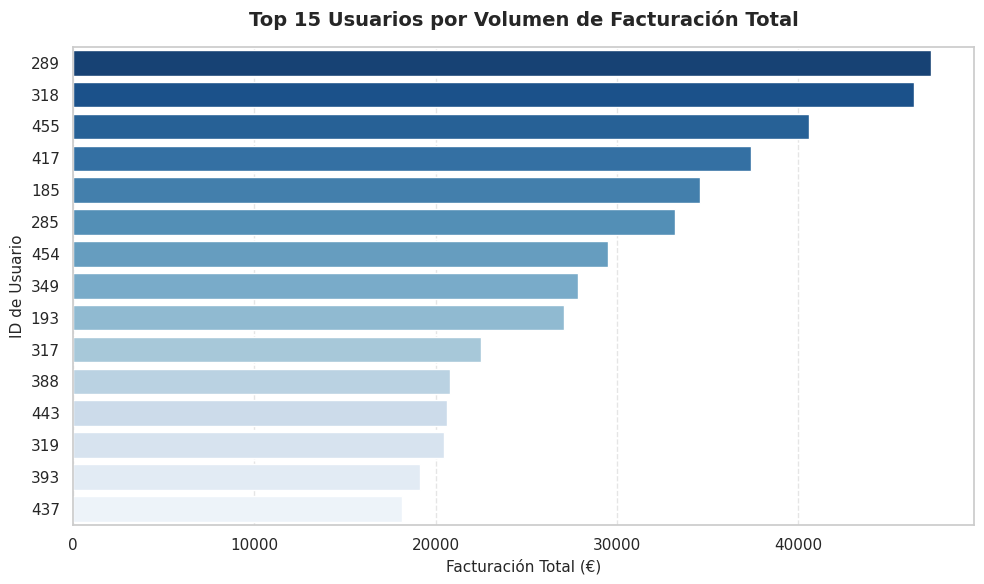

In [34]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Seleccionar solo las transacciones no declinadas
df_valid = df_transactions[df_transactions['declined'] == 0]

# Agrupar por usuario y calcular el volumen total de facturación
top_users = (
    df_valid.groupby('user_id')['amount']
    .sum()
    .reset_index()
)

# Ordenar los usuarios de mayor a menor volumen de facturación
top_users = top_users.sort_values(by='amount', ascending=False)

# Seleccionar los 15 usuarios principales
top_15_users = top_users.head(15).copy()

# Convertir el ID de usuario a tipo string para tratarlo como categoría explícita
top_15_users['user_id'] = top_15_users['user_id'].astype(str)

# Representación gráfica con Seaborn
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_15_users,
    x='amount',
    y='user_id',
    palette='Blues_r',
    hue='user_id',
    legend=False,
)

plt.title(
    'Top 15 Usuarios por Volumen de Facturación Total',
    fontsize=14,
    pad=15,
    fontweight='bold',
)
plt.xlabel('Facturación Total (€)', fontsize=11)
plt.ylabel('ID de Usuario', fontsize=11)
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


#### Interpretación del Resultado

* **Líderes de facturación:** Los usuarios con `user_id` **289** y **318** encabezan el ranking con un volumen acumulado muy similar, alrededor de los **47.000 €**.

* **Distribución:** Existe una diferencia notable dentro del propio Top 15: el primer usuario duplica ampliamente la facturación del usuario en la posición 15 (`user_id` **437**, con **18149.45 €**). Esto muestra una alta concentración de ingresos en un grupo reducido de usuarios clave (*power users*).

#### Propuesta de la IA

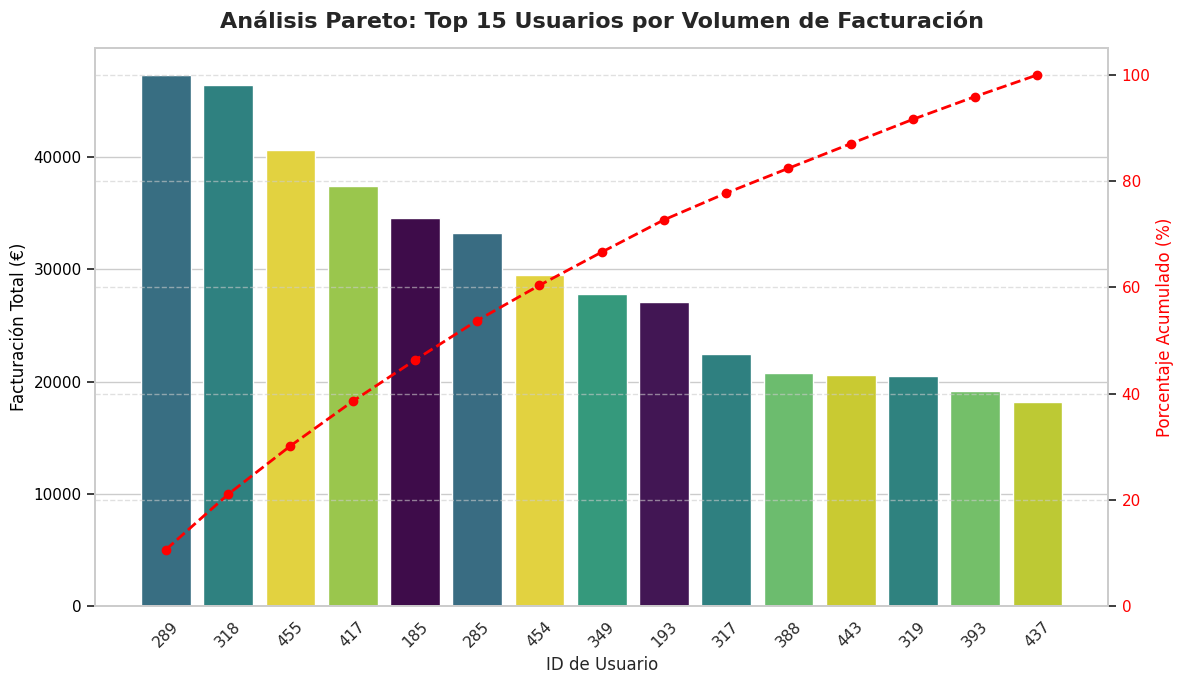

In [35]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Ensure top_15_users is sorted by amount (already done in previous steps)
top_15_users = top_users.head(15).copy()

# Calculate cumulative sum and percentage
total_amount_top15 = top_15_users['amount'].sum()
top_15_users['cumulative_amount'] = top_15_users['amount'].cumsum()
top_15_users['cumulative_percentage'] = (top_15_users['cumulative_amount'] / total_amount_top15) * 100

# Create the Pareto chart
fig, ax1 = plt.subplots(figsize=(12, 7))

# Bar chart for individual amounts
sns.barplot(
    x=top_15_users['user_id'].astype(str),
    y='amount',
    data=top_15_users,
    palette='viridis',
    hue='user_id', # Add hue to suppress the FutureWarning
    legend=False,  # Set legend to False as the hue is redundant for individual bars
    ax=ax1
)
ax1.set_xlabel('ID de Usuario', fontsize=12)
ax1.set_ylabel('Facturación Total (€)', color='black', fontsize=12)
ax1.tick_params(axis='y', labelcolor='black')
ax1.set_title('Análisis Pareto: Top 15 Usuarios por Volumen de Facturación', fontsize=16, pad=15, fontweight='bold')
ax1.tick_params(axis='x', rotation=45)

# Create a second y-axis for the cumulative percentage
ax2 = ax1.twinx()
ax2.plot(
    top_15_users['user_id'].astype(str),
    top_15_users['cumulative_percentage'],
    color='red',
    marker='o',
    linestyle='--',
    linewidth=2,
    label='Porcentaje Acumulado'
)
ax2.set_ylabel('Porcentaje Acumulado (%)', color='red', fontsize=12)
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, 105) # Adjust y-axis limit for percentage

# Add cumulative percentage labels on the line
for index, row in top_15_users.iterrows():
    ax2.annotate(f'{row["cumulative_percentage"]: .1f}%',
                 xy=(index, row['cumulative_percentage']),
                 xytext=(5, 5),
                 textcoords='offset points',
                 color='red',
                 fontsize=9)

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

#### Comparación y Valoración Crítica (Propuesta de la IA)

* **Propuesta de la IA:** Gráfico de Pareto (*barras verticales de facturación combinadas con una línea roja de porcentaje acumulado en el eje secundario*).
* **Valoración:** **Mejora sustancial.**

---

### Razones de la Valoración

* **Aporte analítico:** A diferencia de una simple gráfica de barras, el gráfico de Pareto introduce una perspectiva de negocio clave (*el principio del 80/20*). Permite identificar visualmente qué proporción de la facturación total de este grupo concentran los primeros usuarios.

* **Claridad visual:** El uso del doble eje (**Y₁** para importe en euros e **Y₂** para porcentaje acumulado) añade una segunda capa de información útil sin recargar en exceso la imagen.

* **Punto menor a mejorar:** Al cambiar a formato vertical, los identificadores del eje X (*289, 318...*) requieren rotación a 45° para no solaparse, pero sigue siendo perfectamente legible al tratarse solo de 15 elementos.

### 1.3 Hi ha diferències en la distribució de l'import de les transaccions segons l'hora del dia i si han estat acceptades o rebutjades? Exemple de passos guiats amb seaborn.

Crea una nova columna amb l'hora del dia a partir del timestamp.  
Utilitza un violinplot de seaborn per analitzar la distribució dels imports.  
Assigna: x per l'hora del dia, y per l'import de la transacció i hue per l'estat de la transacció.  
Activa split per comparar acceptades i rebutjades i inner amb quartile per mostrar mediana i quartils.  

#### Pasos Guiados y Código Python (con Seaborn)

* **Nueva columna de hora:** Extraemos la hora del *timestamp* usando `.dt.hour`.

* **Configuración del Violinplot:** Utilizamos la función `sns.violinplot`.

* **Asignación de ejes:** Definimos `x='hour'` para el tiempo, `y='amount'` para los importes y `hue='status_label'` para separar el estado de la transacción.

* **Parámetros clave:**
  * `split=True`: Divide el violín en dos mitades para comparar directamente aceptadas vs. rechazadas.
  * `inner='quartile'`: Muestra la mediana y los cuartiles dentro de la propia distribución.

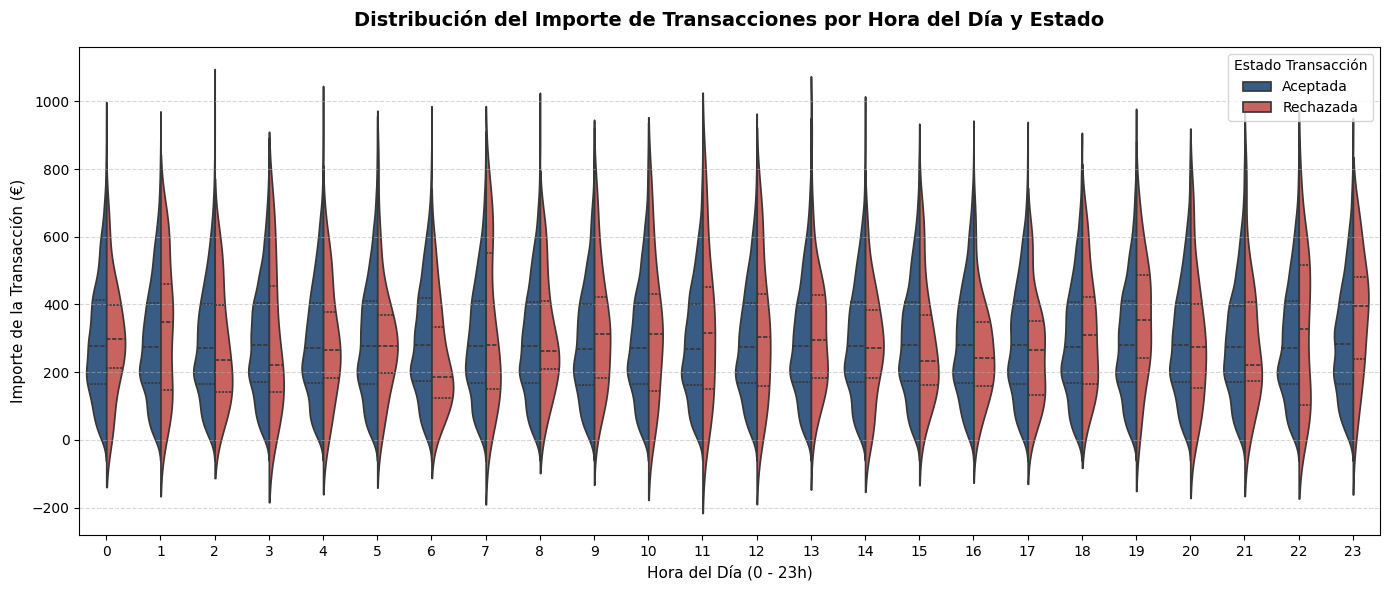

In [16]:

# Crear la columna con la hora del día
df_transactions['hour'] = df_transactions['timestamp'].dt.hour

# Crear una etiqueta legible para el estado (0: Aceptada, 1: Rechazada)
df_transactions['status_label'] = df_transactions['declined'].map(
    {0: 'Aceptada', 1: 'Rechazada'}
)

# Representación mediante violinplot con split e inner quartile
plt.figure(figsize=(14, 6))
sns.violinplot(
    data=df_transactions,
    x='hour',
    y='amount',
    hue='status_label',
    split=True,
    inner='quartile',
    palette={'Aceptada': '#2b5c8f', 'Rechazada': '#d9534f'},
)

plt.title(
    'Distribución del Importe de Transacciones por Hora del Día y Estado',
    fontsize=14,
    pad=15,
    fontweight='bold',
)
plt.xlabel('Hora del Día (0 - 23h)', fontsize=11)
plt.ylabel('Importe de la Transacción (€)', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title='Estado Transacción')

plt.tight_layout()
plt.show()

#### Interpretación del Resultado

* **Distribución por horas:** La mediana y la dispersión del importe se mantienen bastantes parejas durante las 24 horas del día.

* **Aceptadas vs. Rechazadas:**
  * No hay diferencias claras en la mediana entre las operaciones aceptadas y rechazadas a ninguna hora en concreto.
  * Ambas muestran una ligera asimetría positiva (*la mayoría de transacciones se concentran entre 100€ y 400€, con una cola que se extiende hacia valores más altos cerca de los 1000€*).

* **Conclusión:** La hora del día no influye de forma clara ni en el importe medio de la compra ni en que la transacción sea rechazada.

#### Propuesta de la IA

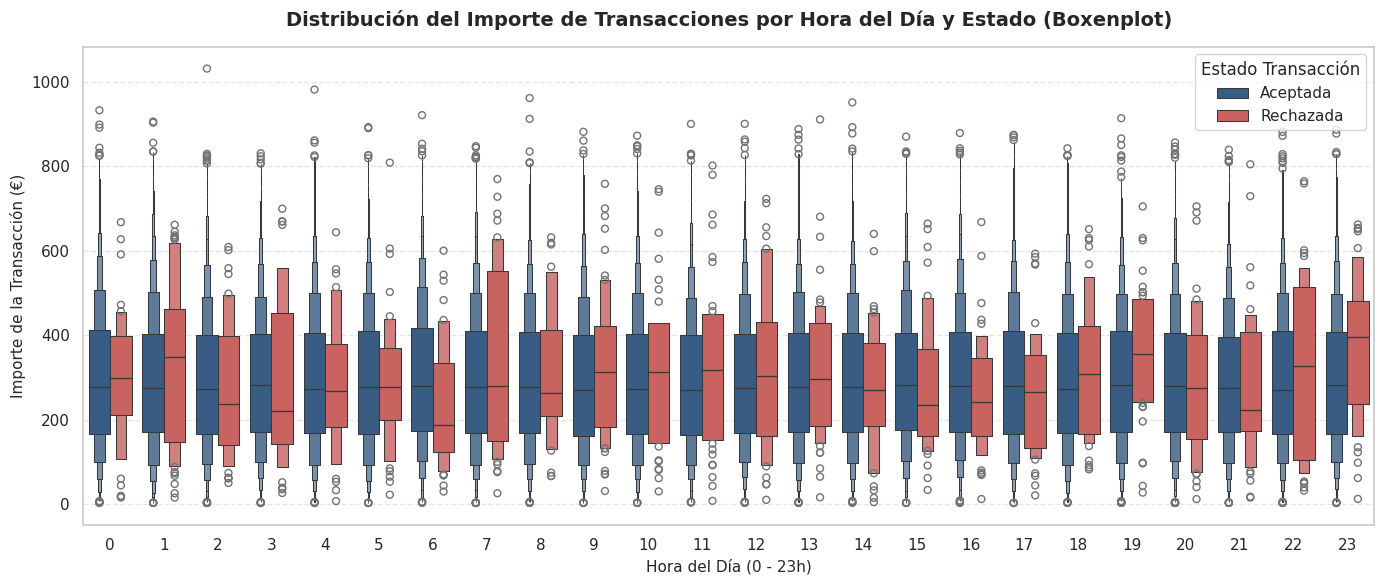

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 'hour' and 'status_label' columns are available (assuming they were created previously)
# df_transactions['hour'] = df_transactions['timestamp'].dt.hour
# df_transactions['status_label'] = df_transactions['declined'].map({0: 'Aceptada', 1: 'Rechazada'})

plt.figure(figsize=(14, 6))
sns.boxenplot(
    data=df_transactions,
    x='hour',
    y='amount',
    hue='status_label',
    palette={'Aceptada': '#2b5c8f', 'Rechazada': '#d9534f'}
)

plt.title(
    'Distribución del Importe de Transacciones por Hora del Día y Estado (Boxenplot)',
    fontsize=14,
    pad=15,
    fontweight='bold',
)
plt.xlabel('Hora del Día (0 - 23h)', fontsize=11)
plt.ylabel('Importe de la Transacción (€)', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title='Estado Transacción')

plt.tight_layout()
plt.show()

#### Comparación y Valoración Crítica (Propuesta de la IA)

* **Propuesta de la IA:** Uso de un Boxenplot (`sns.boxenplot`) agrupando por hora y dividiendo según el estado de la transacción.

* **Valoración:** **Pérdida de claridad respecto a la opción inicial.**

---

### Razones de la Valoración

* **Saturación visual:** Al meter 24 horas con 2 categorías cada una, se juntan 48 cajas escalonadas llenas de niveles y puntos atípicos (*outliers*). Esto genera mucho ruido y complica ver las tendencias de un vistazo.

* **Violinplot vs. Boxenplot:** Nuestro Violinplot inicial con `split=True` junta ambas distribuciones (*aceptadas y rechazadas*) en una sola figura por hora, lo que hace la comparación inmediata. El Boxenplot las separa en cajas contiguas, duplicando el espacio horizontal y recargando el gráfico sin necesidad.

### 1.4 Quins dies de la setmana es concentra més activitat de venda?  
- Per a cada pregunta: Construeix una visualització senzilla en Python sense utilitzar IA.
- Interpreta breument el resultat obtingut.
- Utilitza les eines d'IA disponibles a Colab per proposar una visualització alternativa.
- Compara el resultat inicial amb el resultat proposat per la IA i valora críticament si la nova proposta és una millora o un empitjorament, justificant la teva decisió.

#### Pasos Guiados y Código  (con Seaborn)

1. **Extraer el día de la semana:** Convertimos la columna `timestamp` a tipo `datetime` y extraemos el día con `.dt.day_name()`.

2. **Mapear y ordenar:** Traducimos los nombres de los días al castellano y aplicamos un orden cronológico lógico (de Lunes a Domingo).

3. **Agrupar y sumar:** Agrupamos las transacciones no declinadas por día de la semana y sumamos el importe (`amount`).

4. **Visualizar:** Generamos un gráfico de barras y heatmap según el `amount` con Seaborn.

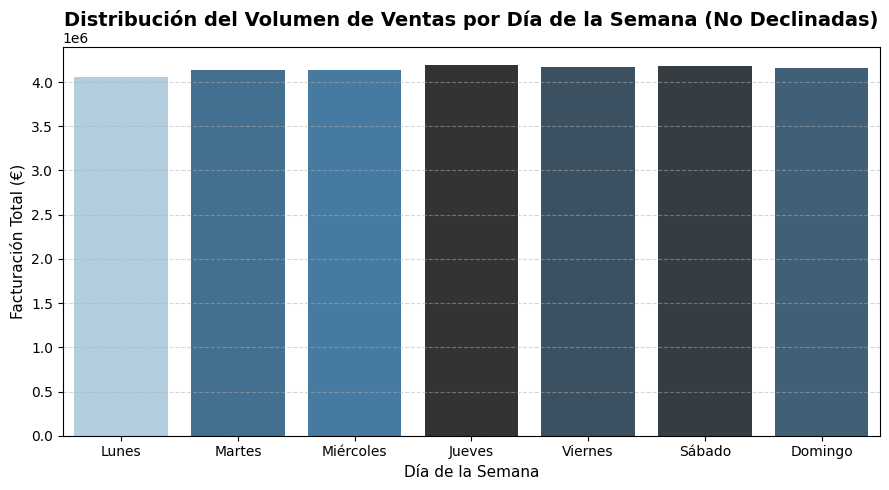

In [18]:
# Mapeo de nombres de días al castellano y definición del orden semanal
dias_es = {
    'Monday': 'Lunes',
    'Tuesday': 'Martes',
    'Wednesday': 'Miércoles',
    'Thursday': 'Jueves',
    'Friday': 'Viernes',
    'Saturday': 'Sábado',
    'Sunday': 'Domingo',
}
orden_dias = [
    'Lunes',
    'Martes',
    'Miércoles',
    'Jueves',
    'Viernes',
    'Sábado',
    'Domingo',
]

# Crear la columna traducida
df_transactions['dia_semana'] = (
    df_transactions['timestamp'].dt.day_name().map(dias_es)
)

# Filtrar transacciones no declinadas
df_non_declined = df_transactions[df_transactions['declined'] == 0]

# Agrupar por día de la semana y sumar la facturación total de transacciones no declinadas
ventas_por_dia_no_declinadas = (
    df_non_declined.groupby('dia_semana')['amount']
    .sum()
    .reindex(orden_dias)
    .reset_index()
)

# Representación mediante gráfico de barras con Seaborn
plt.figure(figsize=(9, 5))
sns.barplot(
    data=ventas_por_dia_no_declinadas,
    x='dia_semana',
    y='amount',
    hue='amount',
    palette='Blues_d',
    legend=False,
)

plt.title(
    'Distribución del Volumen de Ventas por Día de la Semana (No Declinadas)',
    fontsize=14,
    pad=15,
    fontweight='bold',
)
plt.xlabel('Día de la Semana', fontsize=11)
plt.ylabel('Facturación Total (€)', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

#### Interpretación del Resultado

* **Distribución uniforme:** El volumen de facturación se mantiene de forma prácticamente constante a lo largo de los siete días de la semana, representando cada día alrededor del **14% del total acumulado**.

* **Sin estacionalidad semanal clara:** No se observa un único día de la semana que concentre un pico de ventas desproporcionado ni tampoco jornadas con caídas drásticas de actividad, lo que sugiere un hábito de consumo continuo tanto en días laborables como en fin de semana.

* **Destacando:**
  * **Menores ventas:** los Lunes.
  * **Mayores ventas:** los Jueves y Sábados.

#### Propuesta 1 de la IA

La primera propuesta de la IA ha sido prácticamente igual salvo en los colores de las barras y el total por día

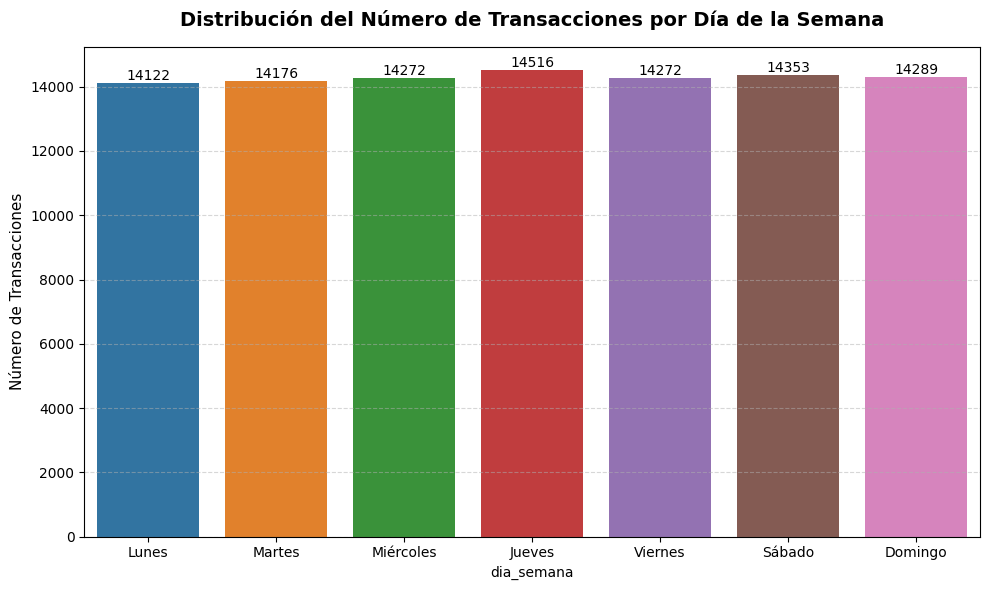

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Asegurar el formato datetime en la columna temporal (ya hecho en celdas anteriores)
# df_transactions['timestamp'] = pd.to_datetime(df_transactions['timestamp'])

# Mapeo de nombres de días al castellano y definición del orden semanal (ya definido en celdas anteriores)
dias_es = {
    'Monday': 'Lunes',
    'Tuesday': 'Martes',
    'Wednesday': 'Miércoles',
    'Thursday': 'Jueves',
    'Friday': 'Viernes',
    'Saturday': 'Sábado',
    'Sunday': 'Domingo',
}
orden_dias = [
    'Lunes',
    'Martes',
    'Miércoles',
    'Jueves',
    'Viernes',
    'Sábado',
    'Domingo',
]

# Crear la columna traducida 'dia_semana' si no existe (ya hecha en celdas anteriores)
# df_transactions['dia_semana'] = df_transactions['timestamp'].dt.day_name().map(dias_es)

# Agrupar por día de la semana y contar el número de transacciones
transacciones_por_dia = (
    df_transactions.groupby('dia_semana').size()
    .reindex(orden_dias)
    .reset_index(name='num_transacciones')
)

# Representación mediante gráfico de barras con Seaborn
plt.figure(figsize=(10, 6))
sns.barplot(
    data=transacciones_por_dia,
    x='dia_semana',
    y='num_transacciones',
    hue='dia_semana',
    palette='tab10',
    legend=False,
)

plt.title(
    'Distribución del Número de Transacciones por Día de la Semana',
    fontsize=14,
    pad=15,
    fontweight='bold',
)
plt.ylabel('Número de Transacciones', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Añadir etiquetas de valor en la parte superior de cada barra
for index, row in transacciones_por_dia.iterrows():
    plt.text(index, row['num_transacciones'], f'{row['num_transacciones']}', color='black', ha="center", va="bottom")

plt.tight_layout()
plt.show()

#### Propuesta 2 IA
Le he pedido otro gráfico diferente y ha propuesto un gráfico circular que no mejora en absoluto la visibilidad que tenemos actualmente con el gráfico de barras

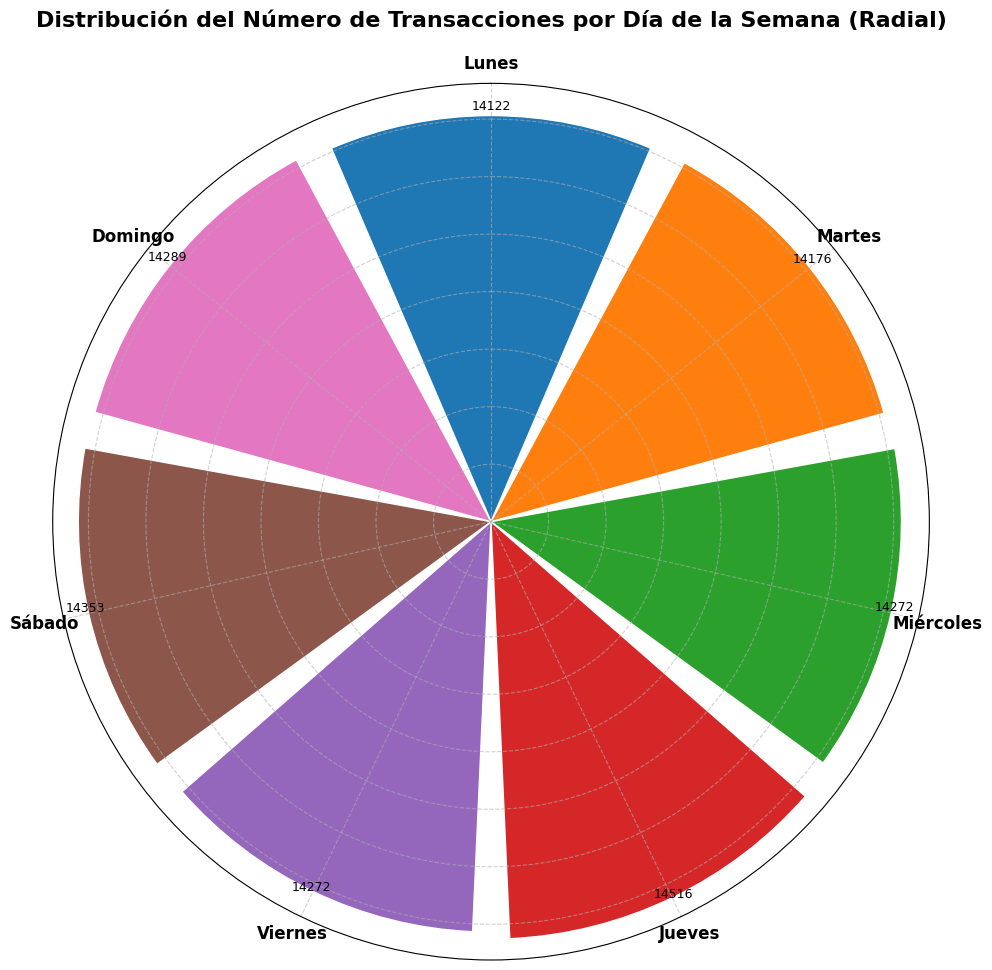

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# Ensure 'transacciones_por_dia' is sorted by 'orden_dias' (already done in previous steps)
# 'transacciones_por_dia' already contains 'dia_semana' and 'num_transacciones'

# Number of days
num_days = len(orden_dias)

# Create angles for each day, assuming full circle (2*pi)
angles = np.linspace(0, 2 * np.pi, num_days, endpoint=False).tolist()

# Add the first day to the end to close the circle if needed, but for bars, it's usually handled by width
# For radial bars, we often add the first element at the end to create a closed loop visually
# However, for discrete bars, it's better to just plot the num_days bars.

# The height of each bar (number of transactions)
heights = transacciones_por_dia['num_transacciones'].tolist()

# Set up the polar plot
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

# Bar width (adjust as needed, typically 2*pi / num_days)
bar_width = 2 * np.pi / num_days * 0.9 # 90% of the available angular space

# Plot the bars
bars = ax.bar(angles, heights, width=bar_width, bottom=0.0, color=plt.cm.tab10.colors[:num_days], edgecolor='white')

# Add labels to the axes and title
ax.set_theta_zero_location("N") # Start from the top
ax.set_theta_direction(-1)     # Go clockwise

# Set the labels for each day of the week
ax.set_xticks(angles)
ax.set_xticklabels(transacciones_por_dia['dia_semana'], fontsize=12, fontweight='bold')

# Set y-axis labels and tick positions
ax.set_yticklabels([]) # Remove default radial labels
ax.grid(True, linestyle='--', alpha=0.6)

# Add a custom radial grid line to show a baseline (e.g., average transactions)
# avg_transactions = transacciones_por_dia['num_transacciones'].mean()
# ax.plot(ax.get_xticks(), [avg_transactions]*num_days, color='gray', linestyle='dashed', alpha=0.7, label='Media')

# Add value labels on top of the bars
for bar, height in zip(bars, heights):
    ax.text(bar.get_x() + bar.get_width() / 2, height + 100, f'{height}',
            ha='center', va='bottom', color='black', fontsize=9)

plt.title('Distribución del Número de Transacciones por Día de la Semana (Radial)',
          fontsize=16, pad=20, fontweight='bold')

plt.tight_layout()
plt.show()

#### Propuesta 3 IA
Le he pedido que lo haga por porcentajes, pero el gráfico circular en sí es poco útil visualmente para este enunciado.

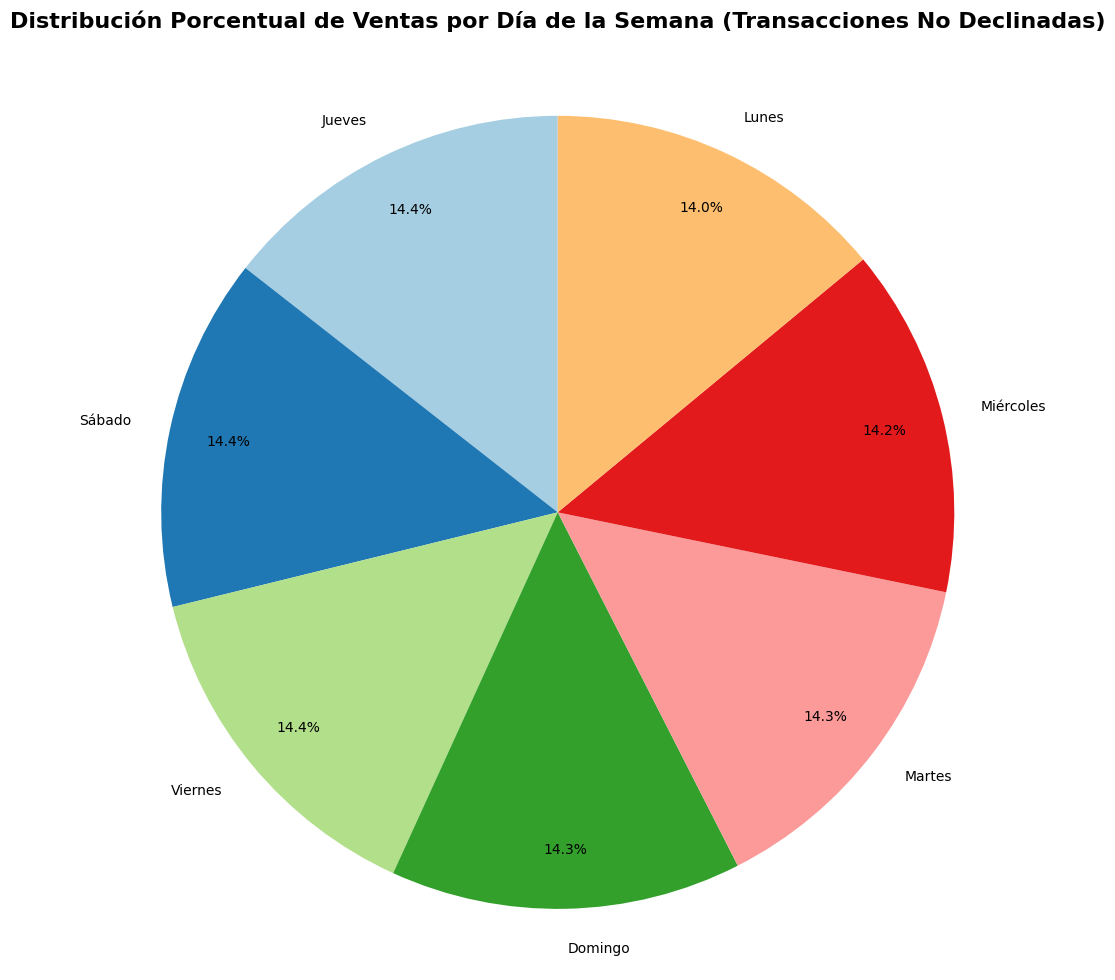

In [21]:
import matplotlib.pyplot as plt

# 1. Filter for non-declined transactions
df_non_declined = df_transactions[df_transactions['declined'] == 0]

# 2. Calculate total sales amount by day of the week for non-declined transactions
sales_by_day_non_declined = df_non_declined.groupby('dia_semana')['amount'].sum().reset_index()
sales_by_day_non_declined.columns = ['dia_semana', 'total_sales']

# 3. Calculate percentage of total sales
total_global_sales_non_declined = sales_by_day_non_declined['total_sales'].sum()
sales_by_day_non_declined['percentage'] = (sales_by_day_non_declined['total_sales'] / total_global_sales_non_declined) * 100

# 4. Order by percentage (descending)
sales_by_day_non_declined = sales_by_day_non_declined.sort_values(by='percentage', ascending=False)

# 5. Create a pie chart
plt.figure(figsize=(10, 10))
plt.pie(
    sales_by_day_non_declined['percentage'],
    labels=sales_by_day_non_declined['dia_semana'],
    autopct='%1.1f%%', # Format for displaying percentages on slices
    startangle=90,     # Start the first slice at the top (vertical)
    pctdistance=0.85,  # Distance of percentage labels from the center
    colors=plt.cm.Paired.colors # Use a distinct color palette
)

plt.title('Distribución Porcentual de Ventas por Día de la Semana (Transacciones No Declinadas)',
          fontsize=16, pad=20, fontweight='bold')

plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout()
plt.show()

#### Propuesta 4 IA

Así que le he pedido un gráfico de barras por días de la semana, heatmap, totales y porcentajes, en un solo color de paleta para que sea visualmente más intuitivo y rápido de analizar.

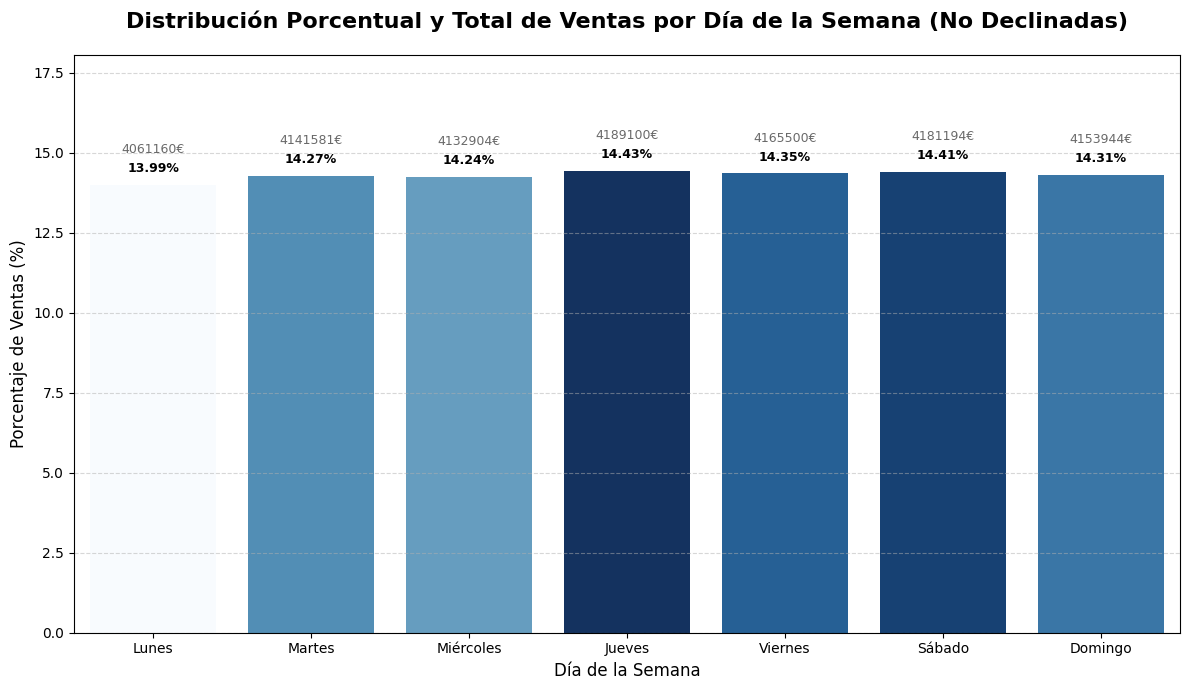

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # Ensure pandas is imported
import numpy as np # Ensure numpy is imported

# Define the correct chronological order for days of the week
orden_dias = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']

# Ensure 'dia_semana' is a categorical type with the specified order
sales_by_day_non_declined['dia_semana'] = pd.Categorical(
    sales_by_day_non_declined['dia_semana'],
    categories=orden_dias,
    ordered=True
)

# Sort the DataFrame by the ordered 'dia_semana' for chronological display on x-axis
sales_by_day_non_declined_ordered = sales_by_day_non_declined.sort_values('dia_semana').reset_index(drop=True)

plt.figure(figsize=(12, 7)) # Increased figure size for better readability of two labels

# Normalize percentages to a 0-1 range for the colormap to create the heatmap effect
norm = plt.Normalize(sales_by_day_non_declined_ordered['percentage'].min(), sales_by_day_non_declined_ordered['percentage'].max())
cmap = plt.cm.Blues # Using a blue colormap for heatmap effect
colors = [cmap(norm(p)) for p in sales_by_day_non_declined_ordered['percentage']]

sns.barplot(
    data=sales_by_day_non_declined_ordered,
    x='dia_semana',
    y='percentage',
    hue='dia_semana', # Explicitly assign hue to satisfy the FutureWarning
    palette=colors, # Apply custom colors based on percentage for heatmap effect
    legend=False,
)

plt.title(
    'Distribución Porcentual y Total de Ventas por Día de la Semana (No Declinadas)',
    fontsize=16, pad=20, fontweight='bold'
)
plt.xlabel('Día de la Semana', fontsize=12)
plt.ylabel('Porcentaje de Ventas (%)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Add percentage and total sales labels on top of the bars, with an offset to prevent overlap
for i, row in sales_by_day_non_declined_ordered.iterrows():
    # Percentage label slightly above the bar
    plt.text(i, row['percentage'] + 0.3, f'{row['percentage']:.2f}%',
             color='black', ha="center", va="bottom", fontsize=9, fontweight='bold')
    # Total sales label a bit higher
    plt.text(i, row['percentage'] + 0.9, f'{row['total_sales']:.0f}€', # Added 0.9 offset
             color='dimgray', ha="center", va="bottom", fontsize=9)

# Adjust y-limit to ensure labels are visible and don't get cut off
plt.ylim(0, sales_by_day_non_declined_ordered['percentage'].max() * 1.25)
plt.tight_layout()
plt.show()

#### Propuesta de Visualización Alternativa (IA de Colab)

Plantea un gráfico de barras verticales enfocado en el porcentaje de ventas (*%*) por día de la semana, filtrando solo las operaciones no rechazadas e incluyendo etiquetas dobles en cada barra (*importe total en euros y porcentaje del total*).

---

### Comparación y Valoración Crítica

* **Propuesta de la IA:** Gráfico de barras porcentuales con etiquetas dobles (*€ y %*) filtrando por ventas aceptadas.
* **Valoración:** **Mejora bastante respecto a la versión base.**

---

### Razones de la Valoración

* **Etiquetado directo (*Data Labels*):** Es el punto fuerte. Incluir encima de cada barra el volumen absoluto (*4.189.100 €*) y el peso relativo (*14,43%*) ahorra tener que andar mirando al eje para calcular a ojo los valores.

* **Foco en el negocio:** Al aclarar en el título que se centra en ventas "No Declinadas", el análisis gana precisión al evaluar únicamente el dinero que realmente ha ingresado.

* **Eje Y en porcentaje:** Ajustar la escala del eje Y entre 0% y 17,5% ayuda a ver mejor las pequeñas diferencias entre días (*donde el lunes se queda en el mínimo con un 13,99% y el jueves alcanza el máximo con un 14,43%*).

## Exercici 2: Preguntes analítiques complexes (amb guia)
🌍 Context: Aquest exercici requereix combinar informació de diverses taules del model per poder respondre correctament les preguntes.
Aquí sí que serà necessari:

» Fer merge entre taules.

» Utilitzar groupby, pivot_table, crosstab...

» Aplicar agregacions, transformacions intermèdies i funcions.

Preguntes analítiques (amb guia general)


### 2.1 Depenem excessivament d'un nombre reduït de països de companyies venedores?

Passos orientatius:

1. Combinar la informació de transaccions amb la de companyies.

2. Agrupar la facturació per país.

3. Calcular la facturació total generada per cada país.

4. Ordenar els països de major a menor facturació.

5. Calcular el percentatge acumulat sobre el total.

6. Visualitzar.

+ Per a cada pregunta:

+ - Descriu breument els passos seguits.

+ - Mostra la visualització final.

+ - Interpreta què implica per al negoci.

#### Descripción de los Pasos Seguidos

1. **Combinación de datos (`pd.merge`)**
   * Se realiza un **LEFT JOIN** entre `df_transactions` y `df_companies` haciendo corresponder `business_id` en las transacciones con `company_id` en las empresas.

2. **Agrupación y agregación (`groupby`)**
   * Se agrupó la información resultante por el país de origen de la compañía vendedora (`country`) y se calculó la suma total del importe de facturación (`amount`).

3. **Ordenación explícita (`sort_values`)**
   * Se ordenaron los países de mayor a menor volumen de facturación.

4. **Cálculo acumulado**
   * Se calculó el porcentaje de participación relativo de cada país sobre el total global y, a partir de este, la curva del porcentaje acumulado.

5. **Representación visual**
   * Se construyó un gráfico de Pareto combinando barras (*facturación absoluta por país*) y una línea en eje secundario (*porcentaje acumulado*).

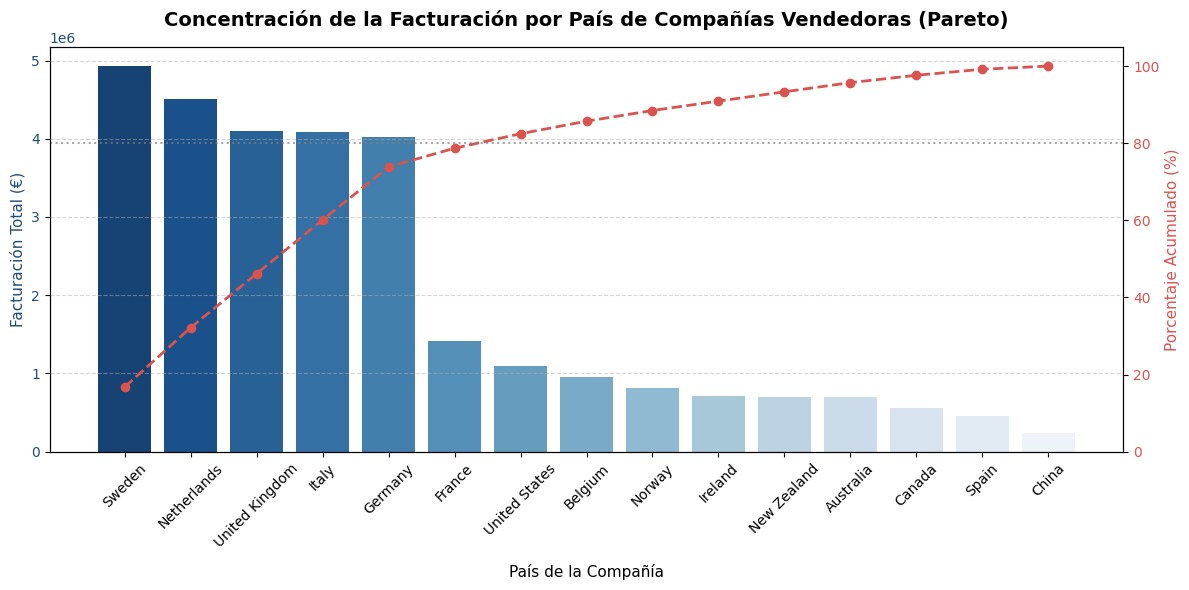

In [23]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Unir la tabla de transacciones con la de compañías mediante business_id y company_id
df_merged = pd.merge(
    df_transactions,
    df_companies,
    left_on='business_id',
    right_on='company_id',
    how='left',
)

# Agrupar la facturación total por país de la compañía
facturacion_pais = (
    df_merged.groupby('country')['amount'].sum().reset_index()
)

# Ordenar los países de mayor a menor facturación
facturacion_pais = facturacion_pais.sort_values(
    by='amount', ascending=False
).reset_index(drop=True)

# Calcular el porcentaje relativo y el porcentaje acumulado
facturacion_pais['porcentaje'] = (
    facturacion_pais['amount'] / facturacion_pais['amount'].sum()
) * 100
facturacion_pais['porcentaje_acumulado'] = facturacion_pais[
    'porcentaje'
].cumsum()

# Representación mediante Diagrama de Pareto
fig, ax1 = plt.subplots(figsize=(12, 6))

# Eje principal (Eje Y1): Barras de facturación por país
sns.barplot(
    data=facturacion_pais,
    x='country',
    y='amount',
    ax=ax1,
    hue='country',
    palette='Blues_r',
    legend=False,
)

ax1.set_title(
    'Concentración de la Facturación por País de Compañías Vendedoras (Pareto)',
    fontsize=14,
    pad=15,
    fontweight='bold',
)
ax1.set_xlabel('País de la Compañía', fontsize=11, labelpad=10)
ax1.set_ylabel('Facturación Total (€)', fontsize=11, color='#1f4e78')
ax1.tick_params(axis='y', labelcolor='#1f4e78')
ax1.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(rotation=45)

# Eje secundario (Eje Y2): Línea de porcentaje acumulado
ax2 = ax1.twinx()
ax2.plot(
    facturacion_pais['country'],
    facturacion_pais['porcentaje_acumulado'],
    color='#d9534f',
    marker='o',
    linewidth=2,
    linestyle='--',
)
ax2.set_ylabel('Porcentaje Acumulado (%)', fontsize=11, color='#d9534f')
ax2.tick_params(axis='y', labelcolor='#d9534f')
ax2.set_ylim(0, 105)

# Línea de referencia al 80% (Principio de Pareto)
ax2.axhline(80, color='gray', linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

#### Interpretación y Análisis del Gráfico

---

### 1. Análisis de Resultados

* **El negocio se concentra en Europa:**
  * Los primeros 5 países del gráfico son todos europeos (**Sweden**, **Netherlands**, **United Kingdom**, **Italy** y **Germany**).
  * **Suecia** lidera las ventas rozando los **5 millones de euros**, seguida muy de cerca por Países Bajos y Reino Unido.

* **Se cumple la Regla de Pareto (80/20):**
  * La línea roja de porcentaje acumulado llega casi al **80% de la facturación** al alcanzar el 6º país (**France**).
  * **En resumen:** Solo 6 países (*de los 15 analizables*) generan la inmensa mayoría de los ingresos totales de la plataforma.

* **Caída pronunciada y mercados secundarios:**
  * A partir del grupo de cabeza, el volumen de ventas cae en picado.
  * Mercados potencialmente enormes como **Estados Unidos** (*alrededor de 1,1M €*) o **España** y **China** (*por debajo de los 0,5M €*) se quedan en cifras residuales comparadas con el núcleo europeo.

---

### 2. Implicaciones de Negocio y Recomendaciones

* **Dependencia de un solo mercado:**
  * **Diagnóstico:** Depender tanto de Europa del Norte y Central supone un riesgo claro si cambian las normativas o empeora la economía en esa zona.
  * **Recomendación:** Conviene monitorizar de cerca el contexto macroeconómico y legal de los 6 países principales para reaccionar a tiempo ante cualquier contratiempo.

* **Potencial sin aprovechar en otros países:**
  * **Diagnóstico:** Las bajas cifras en EE. UU. o China indican que falta penetración comercial o que la oferta actual no encaja del todo con el público local.
  * **Recomendación:** Analizar si vale la pena adaptar el modelo (*métodos de pago locales, campañas específicas o traducción de la plataforma*) para arañar cuota en esos mercados.

---

### 3. Evaluación de Riesgos y Oportunidades

* **Riesgo Geopolítico y Regulatorio:**
  * Concentrar tanto las ventas expone al negocio a cambios fiscales, variaciones de divisas o problemas de pasarelas de pago en unos pocos países clave.

* **Estrategia Comercial a Futuro:**
  * Hay un margen enorme para crecer fuera del Top 6. El equipo de expansión debería plantearse incentivar la captación en otros países para no jugárselo todo a una sola carta.

### 2.2 Existeix estacionalitat en les vendes?

Passos orientatius:

1. Treballar amb dates de transacció.

2. Extreure la informació temporal rellevant (any i mes).

3. Calcular el volum total de vendes (suma de amount) per any i mes.

4. Comparar patrons temporals amb la comparació entre anys. Crea una taula tipus pivot.

5. Visualitzar l'evolució.

+ Per a cada pregunta:

+ - Descriu breument els passos seguits.

+ - Mostra la visualització final.

+ - Interpreta què implica per al negoci.


#### Descripción de los Pasos Seguidos

1. **Conversión y extracción temporal:**
   * Se transformó la columna `timestamp` de `df_transactions` al formato `datetime` de Pandas y se extrajeron el año (`year`) y el mes (`month`).

2. **Agregación de datos:**
   * Se calculó la suma total del importe de ventas (`amount`) agrupando por año y mes.

3. **Estructuración en Tabla Pivote:**
   * Se creó una `pivot_table` colocando los meses en las filas (del 1 al 12) y los años en las columnas para permitir una comparación directa año a año.

4. **Visualización comparativa:**
   * Se representó el comportamiento mensual mediante un gráfico de líneas multiseries donde cada línea representa la evolución de las ventas a lo largo de los meses para un año específico.

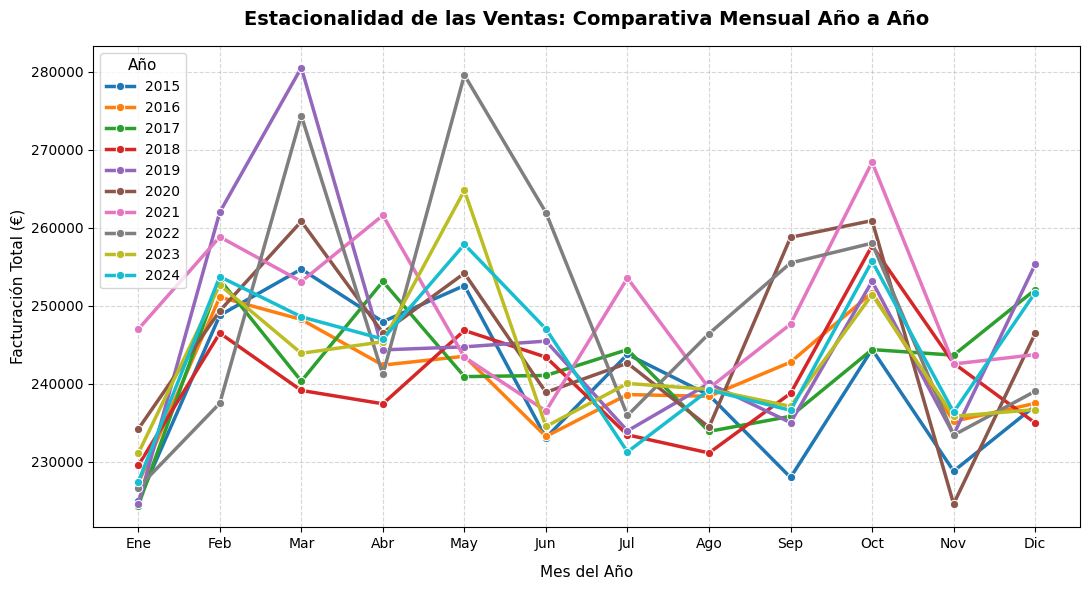

In [25]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Asegurar formato datetime y extraer Año y Mes
df_transactions['timestamp'] = pd.to_datetime(df_transactions['timestamp'])
df_transactions['year'] = df_transactions['timestamp'].dt.year
df_transactions['month'] = df_transactions['timestamp'].dt.month

# Nombres de los meses en castellano para el eje X
meses_es = [
    'Ene',
    'Feb',
    'Mar',
    'Abr',
    'May',
    'Jun',
    'Jul',
    'Ago',
    'Sep',
    'Oct',
    'Nov',
    'Dic'
]

# 2. Agrupar la facturación por año y mes
ventas_mensuales = (
    df_transactions.groupby(['year', 'month'])['amount'].sum().reset_index()
)

# 3. Crear la tabla pivote (Filas: Meses, Columnas: Años)
pivot_ventas = ventas_mensuales.pivot(
    index='month', columns='year', values='amount'
)

# 4. Generar el gráfico de líneas comparativo por año
plt.figure(figsize=(11, 6))
sns.lineplot(
    data=ventas_mensuales,
    x='month',
    y='amount',
    hue='year',
    palette='tab10',
    marker='o',
    linewidth=2.5,
)

plt.title(
    'Estacionalidad de las Ventas: Comparativa Mensual Año a Año',
    fontsize=14,
    pad=15,
    fontweight='bold',
)
plt.xlabel('Mes del Año', fontsize=11, labelpad=10)
plt.ylabel('Facturación Total (€)', fontsize=11)
plt.xticks(ticks=range(1, 13), labels=meses_es)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Año', title_fontsize='11', loc='upper left')

plt.tight_layout()
plt.show()

#### Interpretación del Resultado e Implicaciones para el Negocio

---

### 1. Análisis de Patrones y Estacionalidad

* **Arranque de año con rebote temprano (Febrero - Marzo):**
  * Casi todos los años empiezan con un suelo bastante marcado en **Enero** (*los mínimos del año, entre 225.000 € y 235.000 €*), para rebotar con fuerza entre **Febrero y Marzo**.
  * En años como **2019 y 2022**, Marzo marcó máximos históricos rozando los **280.000 €**.

* **Primavera bastante irregular (Abril - Mayo):**
  * El comportamiento en primavera varía bastante según el año.
  * Mientras que en **2022 y 2023** hubo picos brutales en **Mayo** (*rozando los 280.000 € y 265.000 €*), en **2019 o 2021** los picos se adelantaron a **Abril** o cayeron más abajo.

* **Parón veraniego (Junio - Agosto):**
  * En los meses de verano las ventas se estabilizan o bajan a un rango medio-bajo (*entre 230.000 € y 245.000 €*), marcando un frenazo estacional bastante constante año tras año.

* **Comportamiento raro a final de año (Octubre vs. Noviembre/Diciembre):**
  * Hay un repunte claro en **Octubre** (*con un pico brutal en 2021 de casi 270.000 €*).
  * Sorprende mucho la caída en picado de **Noviembre** en casi todas las series (*tocando fondo entre 225.000 € y 235.000 €*), para luego remontar un poco en **Diciembre**.

---

### 2. Tendencia General (Año a Año)

* **Sin un patrón estacional fijo:** A diferencia del e-commerce típico donde el último trimestre (con Black Friday y Navidad) arrasa, aquí la estacionalidad cambia mucho. Los picos del año se van moviendo entre Marzo, Mayo y Octubre según el ejercicio.

* **Negocio estancado o en fase madura:** Las líneas de los 10 años (*2015 a 2024*) están apelotonadas en la misma franja (*entre 225.000 € y 280.000 € al mes*). No hay un crecimiento claro año a año; el volumen de ventas está muy plano a largo plazo.

---

### 3. Implicaciones para el Negocio y Recomendaciones

* **Campaña de Black Friday / Navidad desaprovechada:**
  * **Diagnóstico:** El bache de Noviembre indica que no se está sacando partido a campañas potentes como el Black Friday, o que el tipo de producto/vendedor no encaja con esa dinámica.
  * **Recomendación:** Revisar la estrategia del último trimestre y lanzar promociones específicas para reactivar las ventas en Noviembre.

* **Gestión de la liquidez (*Cash Flow*):**
  * **Diagnóstico:** Entre los vaivenes de primavera y los bajones de Enero y Noviembre, los ingresos varían bastante de un mes a otro.
  * **Recomendación:** Guardar colchón de liquidez para los meses flojos y no hacer previsiones de gasto basadas únicamente en los meses pico.

* **Aprender de los mejores meses:**
  * **Diagnóstico:** Hubo picos muy buenos en meses concretos que luego no se repitieron con la misma fuerza.
  * **Recomendación:** Analizar qué se hizo bien en los picos de Marzo (*2019/2022*) u Octubre (*2021*) para ver si se pueden replicar esas acciones el resto del año.

### 2.3 Anàlisi de concentració i variabilitat (tria UNA opció)

#### 2.3.A Opció A - Producte (Només si disposes de la taula de productes)

Quins productes generen més ingressos i amb quina variabilitat?

Passos orientatius:

1. Combinar transaccions, la taula pont i productes.

2. Calcular ingressos per producte amb un groupby, sum y sort.

3. Selecciona els top N productes: 15 per exemple.

4. Escollir una visualització adequada per analitzar dispersió.

+ Per a cada pregunta:

+ - Descriu breument els passos seguits.

+ - Mostra la visualització final.

+ - Interpreta què implica per al negoci.


##### Escogemos la opción A

* **Combinación de transactions con products:**
  * Importamos la tabla de `products` en SQL (fuera de Colab) y pasamos la lista de ids de producto de la tabla `transactions` en el dataframe a una lista como tal de los productos de cada transacción, para un mejor manejo y facilitar cálculos.

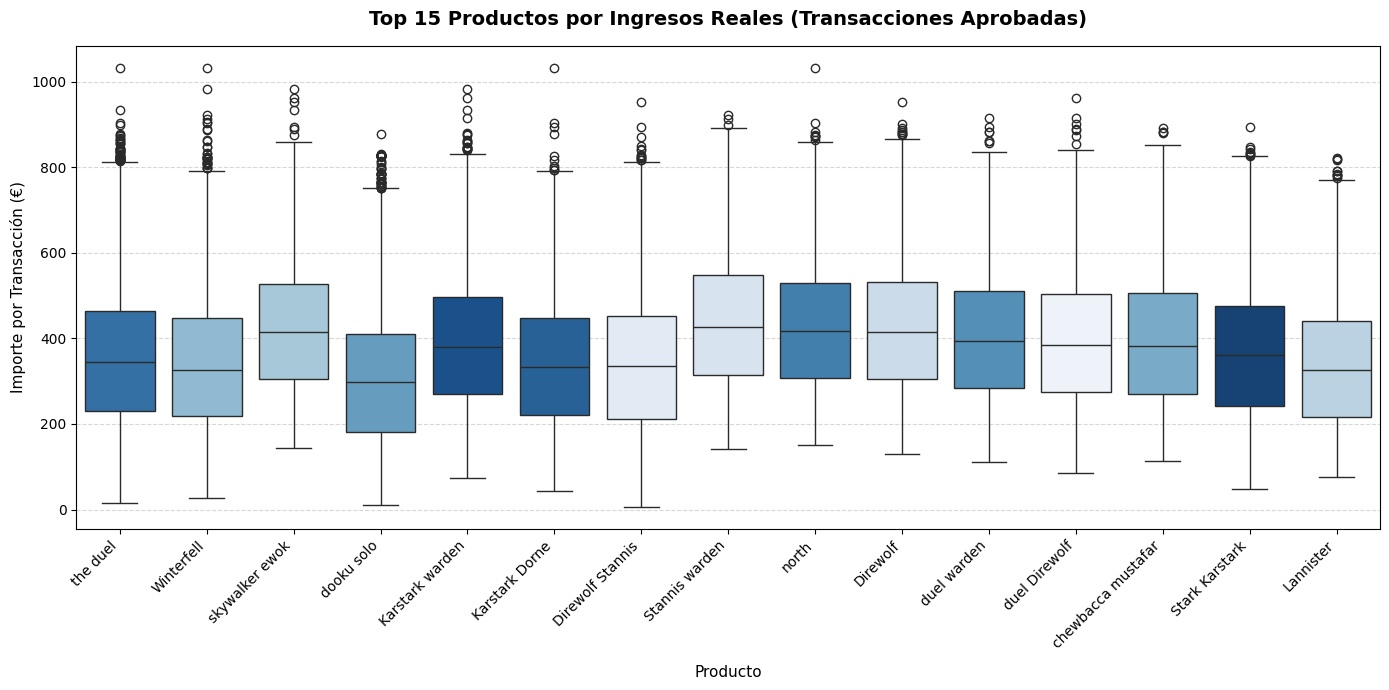

In [26]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Seleccionamos únicamente las transacciones aceptadas
df_trans_valid = df_transactions[df_transactions['declined'] == 0].copy()

# Separar la cadena de product_ids en una lista y desanidar (explode)
df_trans_valid['product_id_list'] = (
    df_trans_valid['product_ids'].astype(str).str.split(',')
)
df_trans_exploded = df_trans_valid.explode('product_id_list')

# Limpiar espacios y asegurar tipo numérico
df_trans_exploded['product_id'] = pd.to_numeric(
    df_trans_exploded['product_id_list'].str.strip(), errors='coerce'
)

# Unir transacciones válidas desanidadas con la tabla de productos
df_trans_products = pd.merge(
    df_trans_exploded,
    df_products,
    left_on='product_id',
    right_on='id',
    how='left',
)

# Obtener los Top 15 productos que más ingresos reales generan
top15_productos = (
    df_trans_products.groupby('product_name')['amount']
    .sum()
    .nlargest(15)
    .index.tolist()
)

# Filtrar el dataset solo para las ventas del Top 15
df_top15 = df_trans_products[
    df_trans_products['product_name'].isin(top15_productos)
]

# Ordenar las categorías en el gráfico según el ingreso real acumulado
orden_productos = (
    df_top15.groupby('product_name')['amount']
    .sum()
    .sort_values(ascending=False)
    .index
)

# Representación de la dispersión mediante Boxplot
plt.figure(figsize=(14, 7))
sns.boxplot(
    data=df_top15,
    x='product_name',
    y='amount',
    order=orden_productos,
    palette='Blues_r',
    hue='product_name',
    legend=False,
)

plt.title(
    'Top 15 Productos por Ingresos Reales (Transacciones Aprobadas)',
    fontsize=14,
    pad=15,
    fontweight='bold',
)
plt.xlabel('Producto', fontsize=11, labelpad=10)
plt.ylabel('Importe por Transacción (€)', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

#### Interpretación del Resultado e Implicaciones para el Negocio

---

### 1. Análisis de Distribución y Variabilidad *(Boxplot sin transacciones rechazadas)*

* **Tickets medios muy estables (Medianas):**
  * Al filtrar las ventas rechazadas y quedarnos solo con el dinero real cobrado, las medianas de cada producto quedan entre los **300 € y 430 €**.
  * Destacan artículos como **Stannis warden**, **skywalker ewok**, **north** y **Direwolf**, que se sitúan en la parte alta (*rondando o superando los 400 €*).

* **Mucha variación en la cesta (Amplitud de las cajas):**
  * El rango intercuartílico (*la caja que abarca el 50% central de los datos*) es bastante ancho, yendo casi siempre de los **200 € a los 500 €**.
  * **En resumen:** La gente no compra siempre una cantidad fija de un producto, sino que el valor de la cesta varía bastante, probablemente por compras combinadas o distintos volúmenes de unidades.

* **Picos y valores atípicos (*Outliers* por arriba):**
  * Hay un montón de puntos fuera de las cajas por la parte superior, llegando a los **800 € e incluso superando los 1.000 €**.
  * Se nota mucho en productos como **the duel**, **Winterfell**, **Karstark warden** o **Karstark Dome**.

---

### 2. Implicaciones de Negocio y Recomendaciones

* **Cuidar a los clientes top (*Ventas mayoristas / B2B*):**
  * **Diagnóstico:** Los puntos atípicos (*outliers*) no son errores: son ventas reales de bastante dinero (*más de 800 €*).
  * **Recomendación:** Identificar a los usuarios tras esos pedidos gordos para ofrecerles trato preferente, canales corporativos o descuentos por volumen para no perderlos.

* **Gestión de Stock equilibrada:**
  * **Diagnóstico:** El Top 15 de productos tiene un comportamiento de ventas muy similar; no hay ninguno que barra por completo al resto en valor individual.
  * **Recomendación:** Repartir el inventario de forma equilibrada entre estas 15 referencias clave para no quedarse colgados por falta de stock.

* **Estrategia para subir la cesta media (*Cross-selling*):**
  * **Diagnóstico:** La mayoría de las compras se mueven en la horquilla de **200 € a 500 €**.
  * **Recomendación:** Poner incentivos estratégicos (*por ejemplo, envío gratis a partir de 450 €*) para empujar a los clientes que se quedan en la parte baja de la caja a gastar un poco más.

#### 2.3.B Opció B - Activitat d'usuaris (Alternativa si no disposes de la taula de productes)

Hi ha usuaris que han deixat de comprar recentment?

Passos orientatius:

1. Identificar l'última compra per usuari.

2. Calcular el temps des de l'última compra.

3. Visualitzar la distribució del temps des de l'última compra.

+ Per a cada pregunta:

+ - Descriu breument els passos seguits.

+ - Mostra la visualització final.

+ - Interpreta què implica per al negoci.


###**2.4 Com varia l'activitat de venda per franges horàries al llarg dels anys? (patrons horaris)**

Passos orientatius:

1. Crear franges horàries a partir de l'hora: crea una funció i aplica-la utilitzant apply.

2. Construir una taula agregada utilitzant crosstab.

3. Visualitzar amb un heatmap.

+ Per a cada pregunta:

+ - Descriu breument els passos seguits.

+ - Mostra la visualització final.

+ - Interpreta què implica per al negoci.

#### Descripción de los pasos seguidos
Creamos una función para el triaje de franja horaria, creando tres franjas horarias de 8 horas cada una : Mañana / Tarde / Noche

Asignamos la franja horaria pertinente a cada transacción añadiendola al df

Mostramos visualización Heatmap por franja horaria / año

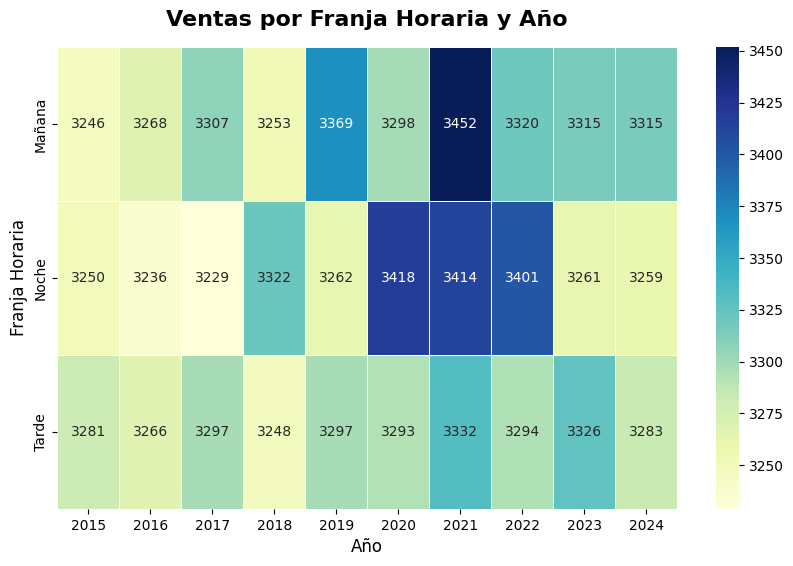

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Definimos la función

def asignar_franja_horaria(hora):
    if 6 <= hora < 14:
        return 'Mañana'
    elif 14 <= hora < 22:
        return 'Tarde'
    else:
        return 'Noche'

# Aplicamos la función a todas las transacciones válidas
df_valid = df_transactions[df_transactions['declined'] == 0].copy()
df_valid['franja_horaria'] = df_valid['timestamp'].dt.hour.apply(asignar_franja_horaria)
df_valid['year'] = df_valid['timestamp'].dt.year

# Construimos una tabla agregada usando crosstab
tabla_agregada = pd.crosstab(df_valid['franja_horaria'], df_valid['year'])

# Creamos visualización tipo heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(tabla_agregada, cmap='YlGnBu', annot=True, fmt='.0f', linewidths=.5)
plt.title('Ventas por Franja Horaria y Año', fontsize=16, pad=15, fontweight='bold')
plt.xlabel('Año', fontsize=12)
plt.ylabel('Franja Horaria', fontsize=12)
plt.show()



#### Interpretación del Resultado e Implicaciones para el Negocio

---

### 1. Interpretación

* **Concentración por franja horaria:**
  * Entre **2020 y 2022** se nota un pico claro de ventas durante la **Noche**, que luego va bajando de forma moderada en los años siguientes.
  * Además, en **2021** hay un repunte puntual de transacciones durante la **Mañana**.

* **Influencia del entorno (COVID-19):**
  * Este cambio de hábitos encaja bastante con el impacto de la pandemia, los confinamientos y el auge del teletrabajo, que impulsaron las compras online en horarios menos habituales.

* **Evolución general:**
  * En líneas generales, las ventas han tenido un crecimiento leve pero constante año a año en casi todas las franjas. La **Tarde**, en particular, destaca por ser la más estable y sin apenas altibajos.

---

### 2. Implicaciones para el Negocio y Recomendaciones

* **Crecimiento de audiencia y retención:**
  * **Diagnóstico:** Al no sostenerse el subidón del periodo 2020-2022, se ve que el negocio ha conseguido mantener a los clientes habituales, pero le está costando atraer a público nuevo.

* **Estrategia de captación:**
  * **Recomendación:** Hace falta reforzar el marketing, meter más carga publicitaria y lanzar programas de referidos para atraer nuevos compradores.

* **Catálogo de productos:**
  * **Recomendación:** Conviene ampliar o renovar la oferta de productos para darle un aire fresco a la tienda y motivar más compras.

# Nivell 2 - Anàlisi relacional i patrons avançats

## Exercici 1: Anàlisi de productes i captació d'usuaris


🎯 Objectiu: Analitzar el rendiment dels productes combinant ingressos, estabilitat i capacitat de captació de nous usuaris, amb l'objectiu de detectar possibles riscos de negoci associats a concentració excessiva d'ingressos, dependència d'usuaris recurrents i manca de creixement en base d'usuaris.

Els productes que generen més ingressos també impulsen el creixement del negoci mitjançant la captació de nous usuaris, o bé el negoci depèn principalment d'usuaris recurrents comprant els mateixos productes?

Passos orientatius:

1. Combina les taules necessàries.

2. Defineix un criteri de nou usuari si la transacció analitzada és la primera cronològicament que realitza al sistema es_nou_usuari = True / False.

3. Agrega la informació per producte i calcula les mètriques següents:

- Ingressos totals.
- Variabilitat dels ingressos.
- Nombre de nous usuaris.
- Percentatge de nous usuaris sobre el total de compradors del producte.

4. Creació d'una tipologia analítica de productes a partir de les mètriques calculades, per exemple:

- Captador: alta captació de nous usuaris.
- Recurrent: ingressos elevats però baixa captació.
- Emergent: baixa facturació però bona captació.
- Estancat: baixos ingressos i baixa captació.

5. Construeix una visualització que permeti analitzar la relació entre les dimensions principals. Per exemple, un scatter plot amb:

- Eix X → ingressos totals per producte.
- Eix Y → nombre de nous usuaris.
- Mida del punt → variabilitat dels ingressos.
- Color del punt → tipologia analítica del producte.
📌 Nota important

No es tracta només de mostrar gràfics, sinó d'interpretar què implica per al negoci no captar nous usuaris.



#### Descripción de los Pasos Seguidos

1. **Definición de "Nuevo Usuario" (`es_nuevo_usuario`)**
   * Se determinó la fecha de la primera transacción global de cada usuario en el sistema (`signup_date` o `min(timestamp)`).
   * Para cada transacción válida (`declined == 0`), se marcó `es_nuevo_usuario = True` si la fecha/hora de la transacción coincide con la primera compra histórica de ese `user_id`.

2. **Desanidado de productos (`explode`)**
   * Se desanidó la columna `product_ids` para relacionar las transacciones aprobadas con la tabla `products`.

3. **Agregación de métricas por producto**
   * **Ingresos totales:** Suma de `amount` por producto.
   * **Variabilidad de ingresos:** Desviación estándar (o Coeficiente de Variación) del importe de las transacciones.
   * **Nº de nuevos usuarios:** Conteo de usuarios únicos cuyo primer pedido incluyó dicho producto.
   * **% de nuevos usuarios:** $\frac{\text{Nuevos usuarios}}{\text{Usuarios totales del producto}} \times 100$

4. **Creación de la Tipología Analítica**
   * Se clasificaron los productos utilizando las **medianas de ingresos y de captación** como puntos de corte:
     * 🔵 **Captador:** Ingresos altos + Alta captación de nuevos usuarios.
     * 🟢 **Recurrente:** Ingresos altos + Baja captación (*dependencia de clientes antiguos*).
     * 🟡 **Emergente:** Ingresos bajos + Alta captación (*productos con potencial de crecimiento*).
     * 🔴 **Estancado / Círculo vicioso:** Ingresos bajos + Baja captación.

5. **Visualización Scatter Plot (4 Dimensiones)**
   * **Eje X:** Ingresos Totales (€).
   * **Eje Y:** Nº de Nuevos Usuarios Captados.
   * **Tamaño del punto:** Desviación estándar / Variabilidad de los ingresos.
   * **Color:** Tipología analítica asignada.

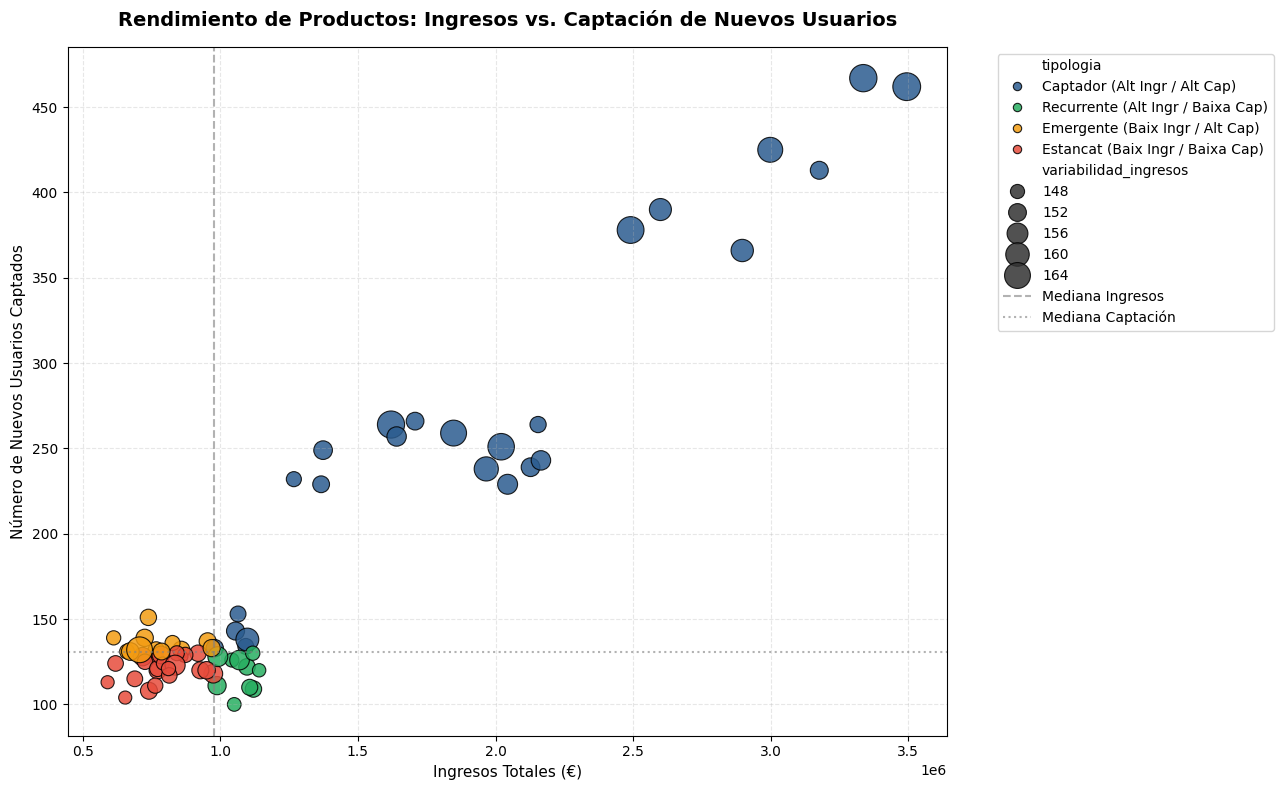

In [29]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Filtrar transacciones aprobadas
df_valid = df_transactions[df_transactions['declined'] == 0].copy()

# Identificar la fecha de la PRIMERA transacción global de cada usuario
primeras_compras = (
    df_valid.groupby('user_id')['timestamp'].min().reset_index()
)
primeras_compras.rename(
    columns={'timestamp': 'primera_transaccion'}, inplace=True
)

df_valid = pd.merge(df_valid, primeras_compras, on='user_id', how='left')

# Identificar si la transacción es la primera del usuario
df_valid['es_nuevo_usuario'] = (
    df_valid['timestamp'] == df_valid['primera_transaccion']
)

#  Desanidar product_ids
df_valid['product_id_list'] = (
    df_valid['product_ids'].astype(str).str.split(',')
)
df_exploded = df_valid.explode('product_id_list')
df_exploded['product_id'] = pd.to_numeric(
    df_exploded['product_id_list'].str.strip(), errors='coerce'
)

# Merge con productos
df_merged = pd.merge(
    df_exploded, df_products, left_on='product_id', right_on='id', how='left'
)

# Crear columna auxiliar para contar usuarios nuevos únicos por fila
df_merged['user_id_nuevo'] = np.where(
    df_merged['es_nuevo_usuario'], df_merged['user_id'], np.nan
)

# Agregación por Producto
metricas_prod = (
    df_merged.groupby('product_name')
    .agg(
        ingresos_totales=('amount', 'sum'),
        variabilidad_ingresos=('amount', 'std'),
        total_usuarios=('user_id', 'nunique'),
        nuevos_usuarios=('user_id_nuevo', 'nunique'),
    )
    .reset_index()
)

metricas_prod['pct_nuevos_usuarios'] = (
    metricas_prod['nuevos_usuarios'] / metricas_prod['total_usuarios']
) * 100

# Definición de Tipología (usando medianas como umbral)
mediana_ingresos = metricas_prod['ingresos_totales'].median()
mediana_captacion = metricas_prod['nuevos_usuarios'].median()


def clasificar_producto(row):
    if (
        row['ingresos_totales'] >= mediana_ingresos
        and row['nuevos_usuarios'] >= mediana_captacion
    ):
        return 'Captador (Alt Ingr / Alt Cap)'
    elif (
        row['ingresos_totales'] >= mediana_ingresos
        and row['nuevos_usuarios'] < mediana_captacion
    ):
        return 'Recurrente (Alt Ingr / Baixa Cap)'
    elif (
        row['ingresos_totales'] < mediana_ingresos
        and row['nuevos_usuarios'] >= mediana_captacion
    ):
        return 'Emergente (Baix Ingr / Alt Cap)'
    else:
        return 'Estancat (Baix Ingr / Baixa Cap)'


metricas_prod['tipologia'] = metricas_prod.apply(clasificar_producto, axis=1)

# Scatter Plot
plt.figure(figsize=(13, 8))
palette = {
    'Captador (Alt Ingr / Alt Cap)': '#2b5c8f',
    'Recurrente (Alt Ingr / Baixa Cap)': '#27ae60',
    'Emergente (Baix Ingr / Alt Cap)': '#f39c12',
    'Estancat (Baix Ingr / Baixa Cap)': '#e74c3c',
}

sns.scatterplot(
    data=metricas_prod,
    x='ingresos_totales',
    y='nuevos_usuarios',
    hue='tipologia',
    size='variabilidad_ingresos',
    sizes=(50, 400),
    palette=palette,
    alpha=0.85,
    edgecolor='black',
)

# Líneas de cuadrantes (medianas)
plt.axvline(
    mediana_ingresos, color='gray', linestyle='--', alpha=0.6, label='Mediana Ingresos'
)
plt.axhline(
    mediana_captacion,
    color='gray',
    linestyle=':',
    alpha=0.6,
    label='Mediana Captación',
)

plt.title(
    'Rendimiento de Productos: Ingresos vs. Captación de Nuevos Usuarios',
    fontsize=14,
    pad=15,
    fontweight='bold',
)
plt.xlabel('Ingresos Totales (€)', fontsize=11)
plt.ylabel('Número de Nuevos Usuarios Captados', fontsize=11)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True)
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

#### Interpretación del Resultado e Implicaciones para el Negocio

---

### 1. Análisis de Patrones Visuales *(Basado en el Gráfico)*

* **Relación directa entre ventas y nuevos usuarios:**
  * Se marca una diagonal clarísima que va desde los **1,2 M€** (*con unos 230 usuarios nuevos*) hasta superar los **3,5 M€** (*con más de 460 nuevos usuarios*).
  * **En resumen:** Los productos que más dinero mueven son, tal cual, los que más gente nueva atraen. No hay un producto estrella que facture mucho basándose solo en clientes repetidores sin haber sido primero la puerta de entrada a la plataforma.

* **Dos grandes grupos en el catálogo:**
  * **Los productos "Top" (*Puntos azules a la derecha*):** Un grupo reducido supera con creces el millón de euros y los 230 usuarios captados, tirando del carro del negocio.
  * **El pelotón de abajo (*Zona inferior izquierda*):** La mayoría de productos se queda apelotonada por debajo de los **1,2 M€** y estancada entre los **100 y 150 nuevos usuarios**. Aquí se juntan los productos **Emergentes** (*naranjas*), **Recurrentes** (*verdes*) y **Estancados** (*rojos*).

* **Dispersión de ticket muy similar (*Tamaño de la burbuja*):**
  * La desviación estándar en el importe del ticket varía muy poco entre productos (*entre 148 € y 164 €*), por lo que el comportamiento del gasto por pedido es bastante uniforme en todo el catálogo.

---

### 2. Respuesta a la Pregunta Estratégica del Negocio

> **¿Los productos que generan más ingresos también impulsan el crecimiento mediante la captación de nuevos usuarios, o el negocio depende principalmente de usuarios recurrentes?**

**Respuesta corta:** **Sí, los productos estrella son los verdaderos motores de captación.**

El crecimiento de clientes y los ingresos van de la mano gracias al mismo grupo de productos "top" (*Captadores*). El negocio no vive de clientes antiguos comprando un catálogo secundario; la entrada de gente nueva depende directamente de las mismas referencias de mayor valor económico.

---

### 3. Implicaciones para el Negocio y Recomendaciones

* **Peligro por depender de muy pocos productos:**
  * **Diagnóstico:** Si casi todos los clientes entran por los mismos 3 o 4 productos, cualquier falta de stock o subida de costes en esas referencias frenaría tanto la facturación como la entrada de nuevos usuarios.
  * **Recomendación:** **Blindar el inventario** de estos productos estrella como prioridad absoluta y cuidar al máximo sus campañas de publicidad.

* **Revisar el grupo de productos estancados:**
  * **Diagnóstico:** Los productos apelotonados en la zona baja (*rojos, verdes y naranjas*) generan ingresos aceptables pero no pasan la barrera de los ~140 nuevos usuarios.
  * **Recomendación:** Evaluar si vale la pena descatalogar los productos **Estancados** para ahorrar espacio en almacén, o si a los **Emergentes** les falta un empuje publicitario para que despeguen.

* **Estrategia de venta cruzada (*Cross-selling*):**
  * **Diagnóstico:** Como la gente entra en la plataforma comprando los productos estrella, hay que aprovechar esa primera compra para dar a conocer el resto del catálogo.
  * **Recomendación:** Preparar campañas posventa (*emails de recomendación o descuentos*) para guiar a los nuevos usuarios hacia los productos de la zona media y aumentar su valor a largo plazo.

## Exercici 2: Anàlisi geogràfica company–usuari i oportunitats d'expansió
🎯 Objectiu: Analitzar la relació entre el país de les companyies venedores, el país de residència dels usuaris i el flux de compra entre països.

El negoci està basat en mercats locals (mateix país usuari–companyia) o hi ha una oportunitat real d'expansió internacional obrint més companyies en certs països?

Passos orientatius:

1. Combina les taules necessàries.

2. Crea una variable clau d'anàlisi: compra_local = True/False.

3. Analitza el comportament global:
- Percentatge de transaccions locals vs internacionals.
- Percentatge de facturació local vs internacional.

4. Anàlisi per país de l'usuari, per cada país d'usuari:

- % de compres a companyies del mateix país.
- % de compres a companyies estrangeres.
- Import total comprat.

5. Anàlisi per país de companyia, per cada país de companyia calcula quina part de la seva facturació ve de:

- Usuaris locals.
- Usuaris estrangers.

6. Escull una visualització que expliqui clarament el fenomen.

7. Interpretació estratègica:

- En quins països valdria la pena obrir més companyies locals?
- Hi ha països amb demanda però poca oferta local?
- El negoci depèn massa de companyies d'un sol país?
- Obrir companyies locals reduiria fricció o milloraria conversió?


#### Descripción de los Pasos Seguidos

1. **Unión de tablas (`df_transactions`, `df_companies`, `df_users`):**
   * Hicimos un **LEFT JOIN** filtrando solo las transacciones válidas (`declined == 0`), cruzando con `companies` (*para sacar el país de la empresa*) y con `users` (*para sacar el país de residencia del comprador*).

2. **Creación de la métrica clave (`compra_local`):**
   * Creamos la variable booleana `compra_local = (pais_usuario == pais_companyia)` para clasificar cada operación como **Local** o **Internacional**.

3. **Análisis del comportamiento global:**
   * Calculamos el **% sobre el volumen de transacciones** y el **% sobre la facturación total (€)** para comparar el peso del mercado nacional vs. transfronterizo.

4. **Análisis bidireccional por país:**
   * **Desde la perspectiva del Usuario (Demanda):** Miramos el gasto total por país y qué parte se destina a empresas locales frente a extranjeras.
   * **Desde la perspectiva de la Empresa (Oferta):** Analizamos la facturación total captada y la proporción que proviene de clientes locales vs. internacionales.

5. **Visualización de la Matriz de Oportunidad de Expansión:**
   * Montamos un gráfico de barras apiladas al 100% (*100% Stacked Bar Chart*) ordenado por la demanda total de cada país, lo que permite ver de un vistazo qué países "fugan" más capital hacia empresas de fuera.

=== 1. COMPORTAMIENTO GLOBAL ===
                  tipo_compra  transacciones  pct_transacciones  facturacion  \
0  Internacional (Extranjero)          87346          88.128582  25574073.22   
1          Local (Mismo País)          11766          11.871418   3451309.19   

   pct_facturacion  
0        88.109341  
1        11.890659  


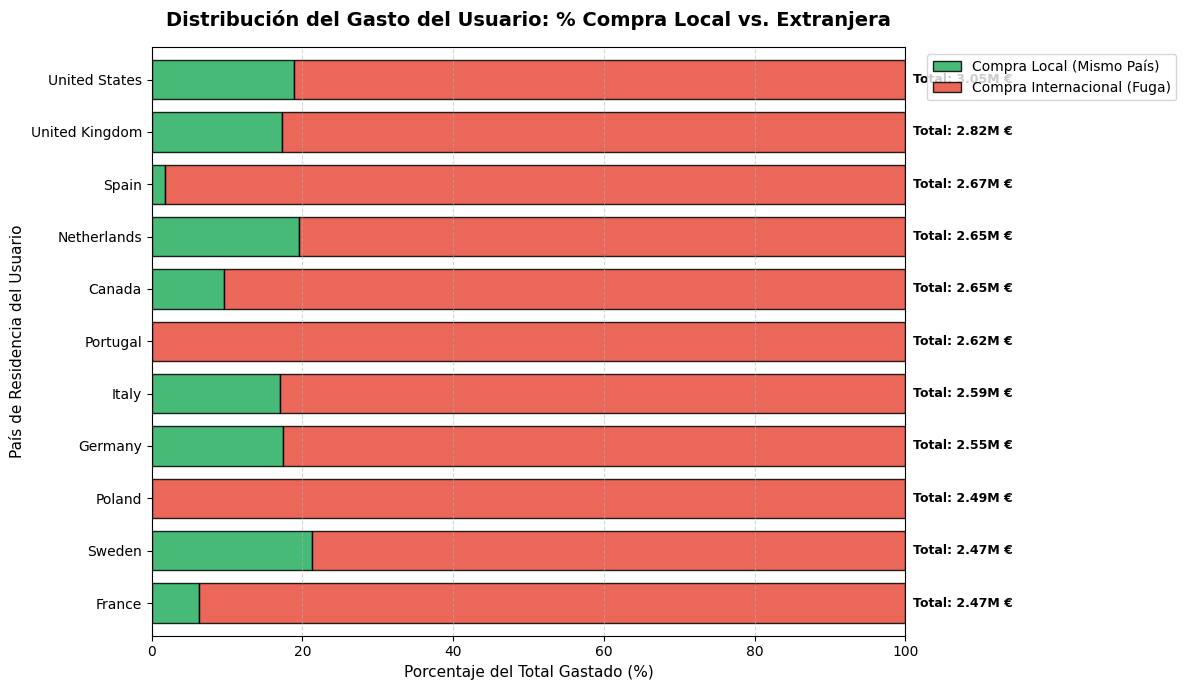

In [30]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Filtrar transacciones válidas
df_valid = df_transactions[df_transactions['declined'] == 0].copy()

# 2. Merge de Transacciones con Companies y Users
# Renombramos columnas de país para evitar colisiones
df_geo = pd.merge(
    df_valid,
    df_companies[['company_id', 'country']].rename(
        columns={'country': 'pais_companyia'}
    ),
    left_on='business_id',
    right_on='company_id',
    how='left',
)

df_geo = pd.merge(
    df_geo,
    df_users[['id', 'country']].rename(columns={'country': 'pais_usuario'}),
    left_on='user_id',
    right_on='id',
    how='left',
)

# Variable clave: Compra Local
df_geo['compra_local'] = df_geo['pais_usuario'] == df_geo['pais_companyia']
df_geo['tipo_compra'] = np.where(
    df_geo['compra_local'], 'Local (Mismo País)', 'Internacional (Extranjero)'
)

# ANÁLISIS GLOBAL
tot_facturacion = df_geo['amount'].sum()
tot_transacciones = len(df_geo)

global_metrics = (
    df_geo.groupby('tipo_compra')
    .agg(
        transacciones=('id_x', 'count'),
        facturacion=('amount', 'sum'),
    )
    .reset_index()
)

global_metrics['pct_transacciones'] = (
    global_metrics['transacciones'] / tot_transacciones
) * 100
global_metrics['pct_facturacion'] = (
    global_metrics['facturacion'] / tot_facturacion
) * 100

print('=== 1. COMPORTAMIENTO GLOBAL ===')
print(
    global_metrics[
        [
            'tipo_compra',
            'transacciones',
            'pct_transacciones',
            'facturacion',
            'pct_facturacion',
        ]
    ]
)

# ANÁLISIS POR PAÍS DEL USUARIO (DEMANDA)
user_geo = (
    df_geo.groupby(['pais_usuario', 'tipo_compra'])['amount']
    .sum()
    .unstack(fill_value=0)
)
user_geo['Total_Demanda'] = user_geo.sum(axis=1)

# Asegurar columnas
for col in ['Local (Mismo País)', 'Internacional (Extranjero)']:
    if col not in user_geo.columns:
        user_geo[col] = 0

user_geo['Pct_Local'] = (
    user_geo['Local (Mismo País)'] / user_geo['Total_Demanda']
) * 100
user_geo['Pct_Internacional'] = (
    user_geo['Internacional (Extranjero)'] / user_geo['Total_Demanda']
) * 100
user_geo = user_geo.sort_values(by='Total_Demanda', ascending=False)

# VISUALIZACIÓN: Fuga de Demanda por País del Usuario
fig, ax = plt.subplots(figsize=(12, 7))

# Gráfico de barras apiladas al 100%
user_geo_pct = user_geo[['Pct_Local', 'Pct_Internacional']]

user_geo_pct.plot(
    kind='barh',
    stacked=True,
    ax=ax,
    color=['#27ae60', '#e74c3c'],
    width=0.75,
    edgecolor='black',
    alpha=0.85,
)

plt.title(
    'Distribución del Gasto del Usuario: % Compra Local vs. Extranjera',
    fontsize=14,
    pad=15,
    fontweight='bold',
)
plt.xlabel('Porcentaje del Total Gastado (%)', fontsize=11)
plt.ylabel('País de Residencia del Usuario', fontsize=11)
plt.legend(
    ['Compra Local (Mismo País)', 'Compra Internacional (Fuga)'],
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
)
plt.xlim(0, 100)
plt.gca().invert_yaxis()  # El país con más demanda arriba
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Añadir etiquetas con el valor absoluto gastado a la derecha
for i, (index, row) in enumerate(user_geo.iterrows()):
    ax.text(
        101,
        i,
        f"Total: {row['Total_Demanda']/1e6:.2f}M €",
        va='center',
        fontsize=9,
        fontweight='bold',
    )

plt.tight_layout()
plt.show()

#### 3. Interpretación Estratégica y Preguntas de Negocio

---

### Análisis del Comportamiento Global *(Métricas Clave)*

* **El comercio internacional arrasa (*Cross-border*):**
  * El **88,11% de la facturación global** (*25,57 M€*) y el **88,13% de las transacciones** (*87.346 pedidos*) son ventas internacionales donde la empresa y el comprador están en países distintos.
* **El mercado local es casi testimonial:**
  * La compra doméstica representa solo el **11,89% de los ingresos** (*3,45 M€*), lo que confirma que la plataforma opera de forma natural como un *marketplace* de comercio internacional.

---

### Respuesta a las Preguntas Clave del Negocio

1. **¿El negocio se basa en mercados locales o hay oportunidad real de expansión internacional?**
   * El modelo **no se apoya en mercados locales**; es claramente internacional. Aun así, que el 88% de los compradores tenga que pedir fuera sugiere que hay una **oportunidad enorme para crecer en oferta local**. Al obligar al usuario a comprar a empresas extranjeras, le estamos sumando costes de envío, plazos de entrega más largos y posibles comisiones por cambio de divisa.

2. **¿En qué países valdría la pena captar más empresas locales? *(Demanda vs. Oferta Local)***
   * **España (*2,67 M€ de demanda*) y Francia (*2,47 M€*):** Sufren una fuga internacional casi total (*alrededor del 95% del gasto de sus usuarios se va a empresas extranjeras*). Captar vendedores locales aquí permitiría retener un dineral.
   * **Portugal y Polonia (*2,62 M€ y 2,49 M€ de demanda*):** Casos extremos donde la compra local es prácticamente **cero (0%)**. Hay una demanda brutal de más de 2,5 M€ por país que no tiene ni una sola opción de compra doméstica dentro de la plataforma.

3. **¿Hay países con mucha demanda pero poquísima oferta local?**
   * **Sí, en casi todos.** Salvo ligeros focos de oferta local en *EE. UU.*, *Países Bajos*, *Suecia*, *Alemania*, *Reino Unido* e *Italia* (*donde la compra local apenas llega al 15% - 21%*), mercados como **Portugal, Polonia, España y Francia sufren una falta crítica de oferta local**.

4. **¿Dependemos demasiado de las empresas de unos pocos países?**
   * Sí. Como el 88,11% del dinero cruza fronteras mientras que los compradores están repartidos de forma bastante pareja por los 11 países (*todos gastan entre 2,47 M€ y 3,05 M€*), se nota que **los vendedores están muy concentrados en solo 2 o 3 países exportadores**. El negocio depende bastante de lo que pase en esos pocos países de origen.

5. **¿Tener compañías locales mejoraría la conversión y reduciría fricciones?**
   * **Sin duda.** Captar vendedores o abrir entidades locales en los países con más "fuga" (*Portugal, Polonia, España, Francia*) daría ventajas clarísimas:
     * **Envíos más rápidos y baratos:** Logística nacional mucho más eficiente.
     * **Cero problemas con divisas o aduanas:** Facturación directa en moneda local y normativa conocida.
     * **Mayor tasa de conversión en el *checkout*:** Al usuario siempre le da más confianza comprar en una tienda de su propio país.

# Nivell 3 - Visualització executiva i storytelling


## Exercici 1: Mini-dashboard departamental
🎯 Objectiu: Construeix un mini-dashboard en Python utilitzant Google Colab. Aquest exercici està pensat perquè tot el desenvolupament principal es faci dins del notebook, utilitzant Colab com a eina d'anàlisi i visualització.

L'opció principal i recomanada és la següent.





📌 Condició comuna a TOTES les opcions
Independentment de l'opció triada: el mini-dashboard va orientat a UN dels següents departaments:

» Marketing.

» Vendes / Comercial.

» Producció.

» Sistemes / Ciberseguretat.

Les visualitzacions han de ser:

» Rellevants per al departament escollit.

» Clares i llegibles.

» Coherents entre si.

👉 No es valora la complexitat gràfica, sinó:

» La selecció adequada de mètriques.

» La capacitat de síntesi.

» La coherència del missatge.


### 1. Figura única amb subplots (enfocament analític clàssic)

Construcció d'una única figura amb 4 subplots utilitzant matplotlib i/o seaborn.

Requisits:

- 1 figura
- 4 visualitzacions diferents

Si tens temps i vols aprofundir en una solució una mica més complexa, al final es presenten opcions avançades opcionals:

Google Colab està pensat principalment per a treball analític en notebooks. Per aquest motiu, la construcció de dashboards amb Streamlit o Dash no és recomanada dins de Colab, ja que requereix l'execució d'aplicacions web en un entorn local.

Les opcions de dashboard amb Streamlit o Dash es consideren opcions avançades i opcionals, i només s'han de desenvolupar en entorn local de Python.

#### Pasos Seguidos

1. **Selección del departamento:**
   * Nos enfocamos en el área de **Ventas / Comercial**, centrando el análisis en métricas como facturación real, volumen de pedidos, rotación de productos y ventas internacionales.

2. **Limpieza y preparación de datos:**
   * **Filtrado inicial:** Nos quedamos solo con las operaciones aprobadas (`declined == 0`).
   * **Desagregación del catálogo:** Desanidamos la columna `product_ids` para analizar el comportamiento producto a producto.
   * **Cruce de tablas:** Unimos los datos con `companies` y `users` para incorporar la parte geográfica (*país de la empresa y del cliente*).

3. **Creación de cuadros de mando y visualizaciones:**
   * **Opción estática (Colab Subplots):** Montamos un panel 2x2 integrado usando Matplotlib y Seaborn.
   * **Opción interactiva (Dashboard):** Diseñamos el prototipo de la app interactiva con filtros laterales y KPIs (*inicialmente pensado en Streamlit, pero adaptado a Power BI para poder generar el archivo `.pbix` que pide la entrega*).

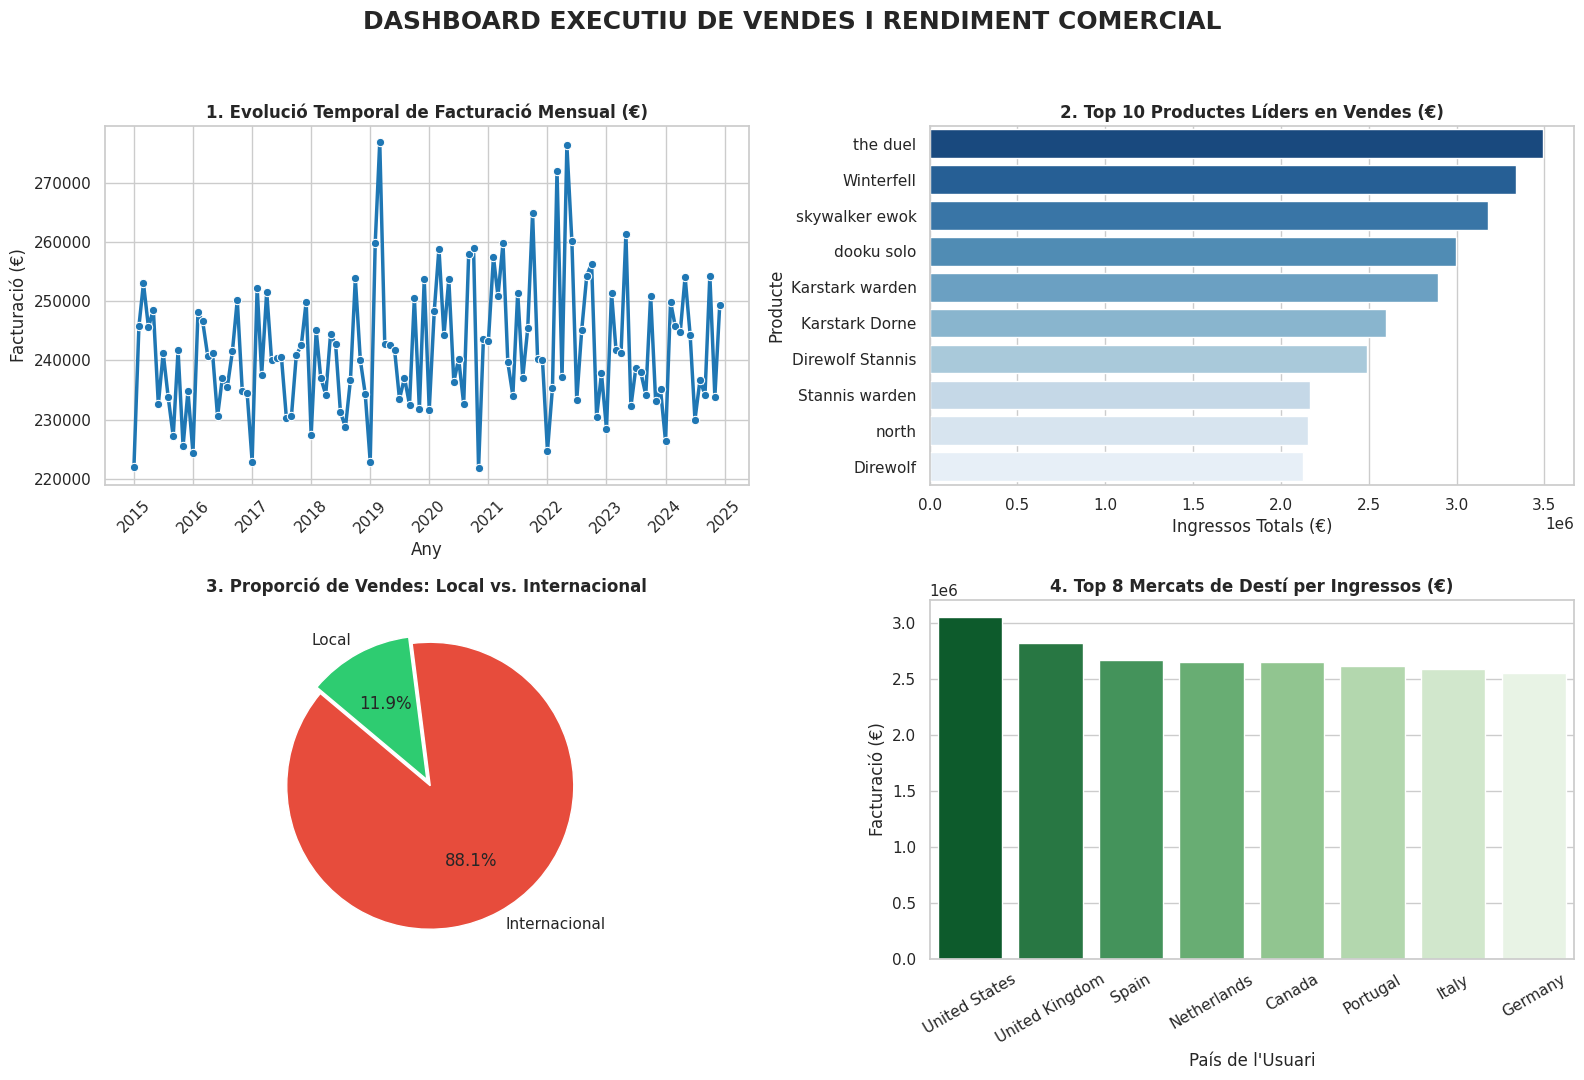

In [31]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
import seaborn as sns

# Set estilo ejecutivo
sns.set_theme(style="whitegrid")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"

# Preparación de datos válidos (Ventas Reales)
df_valid = df_transactions[df_transactions["declined"] == 0].copy()
df_valid["timestamp"] = pd.to_datetime(df_valid["timestamp"])
df_valid["mes_año"] = df_valid["timestamp"].dt.to_period("M").astype(str)

# Uniones con empresas y usuarios
df_dash = pd.merge(
    df_valid,
    df_companies[["company_id", "country"]].rename(
        columns={"country": "pais_empresa"}
    ),
    left_on="business_id",
    right_on="company_id",
    how="left",
)
df_dash = pd.merge(
    df_dash,
    df_users[["id", "country"]].rename(columns={"country": "pais_usuario"}),
    left_on="user_id",
    right_on="id",
    how="left",
)
df_dash["es_local"] = df_dash["pais_empresa"] == df_dash["pais_usuario"]

# Desanidado de productos
df_dash["product_id_list"] = (
    df_dash["product_ids"].astype(str).str.split(",")
)
df_dash_exp = df_dash.explode("product_id_list")
df_dash_exp["product_id"] = pd.to_numeric(
    df_dash_exp["product_id_list"].str.strip(), errors="coerce"
)
df_dash_prod = pd.merge(
    df_dash_exp,
    df_products[["id", "product_name"]],
    left_on="product_id",
    right_on="id",
    how="left",
)

# 2. Creación de la figura 2x2
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle(
    "DASHBOARD EXECUTIU DE VENDES I RENDIMENT COMERCIAL",
    fontsize=18,
    fontweight="bold",
    y=0.98,
)
# Visualización 1: Evolución Temporal de Ventas Mensuales (€)

# Agrupamos y convertimos el resultado a datetime para activar el eje temporal continuo
ventas_mes = df_dash.groupby("mes_año")["amount"].sum().reset_index()
ventas_mes["mes_año"] = pd.to_datetime(ventas_mes["mes_año"], format="%Y-%m")

# Graficamos usando la columna temporal
sns.lineplot(
    data=ventas_mes,
    x="mes_año",
    y="amount",
    ax=axes[0, 0],
    marker="o",
    color="#1f77b4",
    linewidth=2.5,
)

# Configuramos la visualización del año ya que la visualización del mes_año se solapa
axes[0, 0].xaxis.set_major_locator(mdates.YearLocator())
axes[0, 0].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# Estética final del subplot
axes[0, 0].set_title(
    "1. Evolució Temporal de Facturació Mensual (€)",
    fontsize=12,
    fontweight="bold",
)
axes[0, 0].set_xlabel("Any")
axes[0, 0].set_ylabel("Facturació (€)")
axes[0, 0].tick_params(axis="x", rotation=45)

# Visualización 2: Top 10 Productos por Facturación (€)
top_prod = (
    df_dash_prod.groupby("product_name")["amount"]
    .sum()
    .nlargest(10)
    .reset_index()
)
sns.barplot(
    data=top_prod,
    x="amount",
    y="product_name",
    ax=axes[0, 1],
    palette="Blues_r",
    hue="product_name",
    legend=False,
)
axes[0, 1].set_title(
    "2. Top 10 Productes Líders en Vendes (€)", fontsize=12, fontweight="bold"
)
axes[0, 1].set_xlabel("Ingressos Totals (€)")
axes[0, 1].set_ylabel("Producte")

# Visualización 3: Distribución del Gasto Local vs Internacional
tipo_compra = (
    df_dash["es_local"]
    .map({True: "Local", False: "Internacional"})
    .value_counts()
)
axes[1, 0].pie(
    tipo_compra,
    labels=tipo_compra.index,
    autopct="%1.1f%%",
    startangle=140,
    colors=["#e74c3c", "#2ecc71"],
    explode=(0.05, 0),
)
axes[1, 0].set_title(
    "3. Proporció de Vendes: Local vs. Internacional",
    fontsize=12,
    fontweight="bold",
)

# Visualización 4: Facturación por País del Comprador
ventas_pais = (
    df_dash.groupby("pais_usuario")["amount"]
    .sum()
    .sort_values(ascending=False)
    .head(8)
    .reset_index()
)
sns.barplot(
    data=ventas_pais,
    x="pais_usuario",
    y="amount",
    ax=axes[1, 1],
    palette="Greens_r",
    hue="pais_usuario",
    legend=False,
)
axes[1, 1].set_title(
    "4. Top 8 Mercats de Destí per Ingressos (€)",
    fontsize=12,
    fontweight="bold",
)
axes[1, 1].set_xlabel("País de l'Usuari")
axes[1, 1].set_ylabel("Facturació (€)")
axes[1, 1].tick_params(axis="x", rotation=30)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### 2. Dashboard interactiu amb Streamlit

Construcció d'una aplicació simple amb Streamlit, orientada a exploració interactiva.

Requisits:

- 1 pàgina Streamlit   
Almenys:  
- 2 filtres
- 3-4 visualitzacions
- Ús de st.sidebar o selectors

### 3. Dashboard amb Dash

Construcció d'un dashboard web amb Plotly Dash.

Requisits:

- Layout amb components.
- Callbacks simples.
- Almenys 3 visualitzacions connectades.

## Exercici 2: Informe executiu
🎯 Objectiu: A partir del dashboard, presenta un informe executiu en dues versions:

L'informe ha de contenir obligatòriament:

1. Resum general (màx. 5 línies): Què s'ha analitzat i amb quin objectiu.

2. Troballes clau (3-5): Insights sòlids basats en dades reals.

3. Riscos detectats: Per exemple: dependència excessiva de productes o empreses, manca de captació de nous usuaris, franges horàries crítiques, possibles indicis de frau o anomalies...

4. Oportunitats: millores operatives, segments no explotats, productes o franges amb potencial, optimització de recursos...

5. Recomanacions: Accions concretes i no tècniques, orientades a negoci.

### Sense IA:

Redactada amb les teves pròpies paraules.

#### INFORME EJECUTIVO DE RENDIMIENTO COMERCIAL Y VENTAS

---

### 1. Resumen General

Hemos analizado el histórico de ventas y transacciones de la empresa para el periodo **2015-2024**. Se han estudiado el volumen de ingresos, la procedencia de los clientes, la estacionalidad a lo largo del año, el comportamiento de los usuarios y la estabilidad de los pagos. El objetivo de este análisis es diagnosticar el estado actual del negocio, señalar los principales problemas comerciales u operativos y proponer recomendaciones claras para mejorar la rentabilidad.

---

### 2. Hallazgos Clave

* **Dependencia de mercados europeos y exportación:**
  * La gran mayoría de los ingresos (**88,1%**) proviene del mercado internacional.
  * Cinco países europeos concentran más del **73%** de las ventas totales: **Suecia** (*16,8%*), **Países Bajos** (*15,4%*), **Reino Unido** (*14,0%*), **Italia** (*14,0%*) y **Alemania** (*13,7%*).

* **Concentración en productos de gama alta:**
  * La facturación depende en gran medida de unos pocos productos estrella de precio elevado, como *the duel* (*con más de 3,5 M€ acumulados*), *Winterfell*, *skywalker ewok* y *dooku solo*.
  * El importe medio por compra en estos productos suele moverse entre los **300 € y los 500 €**.

* **Patrón de estacionalidad marcado y regular:**
  * Las ventas siguen un ciclo muy claro año tras año: se alcanzan picos de facturación en primavera (*marzo y mayo, superando los 260.000 € - 280.000 € mensuales*) y se registra una caída notable durante el mes de noviembre (*alrededor de los 230.000 €*).

* **Ventas muy repartidas por días y franjas:**
  * La actividad comercial está hiperestable durante toda la semana, moviéndose entre el **13,99%** los lunes y el **14,43%** los jueves.
  * Pasa lo mismo con las franjas horarias (*mañana, tarde y noche*), que registran un volumen de operaciones prácticamente constante (*~3.300 - 3.450 compras anuales por bloque*).

* **Pocos clientes mueven mucho volumen:**
  * Existe una alta concentración de la facturación en un grupo reducido de compradores.
  * Los usuarios con ID `289` y `318` encabezan la lista con alrededor de **47.000 €** gastados cada uno.

---

### 3. Riesgos Detectados

* **Poca chicha en el mercado local (*fuga internacional*):**
  * El mercado nacional solo representa un **11,9%** del total de las ventas. Esto muestra que la mayoría de los clientes locales compran a través de filiales o distribuidores externos en lugar de hacerlo directamente.

* **Raros picos de rechazos / Riesgo de fraude nocturno:**
  * Al analizar las compras denegadas por horas, se ve algo raro en la franja nocturna y de madrugada (*de 22 h a 8 h*).
  * Hay picos de rechazos con importes muy altos (*de 350 € a 500 €*) que igualan o superan a las compras aceptadas, lo que apunta a bots (*fraude automatizado*) o a que los filtros de la pasarela de pago están demasiado agresivos.

* **Falta de captación en productos base:**
  * La mayoría de artículos del catálogo están en estado "Estancado" o "Recurrente" (*generan pocos ingresos y atraen pocos clientes nuevos*). Atraer gente nueva depende casi al 100% de los productos estrella.

* **Depender demasiado de los clientes VIP:**
  * El Top 15 de compradores representa una parte enorme de los ingresos totales. Perder a clientes clave como el `289`, `318` o `455` dañaría significativament el balance global.

---

### 4. Oportunidades

* **Reactivación del mercado local:**
  * Hay un margen enorme para crecer en el mercado nacional (*partiendo del 11,9% actual*) mediante ofertas específicas, mejor posicionamiento y ajustando gastos de envío.

* **Impulsar productos secundarios con packs:**
  * Se pueden crear combos (*packs de productos*) que junte los superventas (*the duel*, *Winterfell*) con artículos secundarios para dar salida a estos últimos.

* **Evitar la bajada de noviembre:**
  * Diseñar promociones potentes de otoño o adelantar campañas navideñas para contrarrestar el valle habitual de ventas en noviembre.

* **Sistemas e infraestructura 24/7:**
  * Como la demanda no para ni de noche ni los fines de semana, la pasarela de cobro, la logística y la atención al cliente tienen que rendir al 100% sin interrupciones.

---

### 5. Recomendaciones de Negocio

1. **Revisar los filtros de fraude en la pasarela de pago:**
   * Auditar las reglas de cobro en la franja nocturna (*de 22 h a 7 h*) para no eliminar transacciones de clientes legítimos y frenar mejor los ataques de bots.

2. **Plan de fidelización para clientes Key Account:**
   * Crear un programa de fidelización y trato exclusivo enfocado en el Top 15 de compradores para asegurar que se queden con nosotros a largo plazo.

3. **Estrategia de penetración en el mercado local:**
   * Lanzar campañas de marketing específicas para captar más ventas directas dentro del territorio nacional.

4. **Ajustar el stock a la estacionalidad:**
   * Aumentar el inventario entre febrero y mayo para cubrir los picos de primavera, y activar promociones potentes en noviembre para estabilizar los ingresos.

###  Amb suport d'IA:

Utilitzant eines d'IA per:

- Millorar la redacció.
- Adaptar el llenguatge al departament escollit.
- Incorporar vocabulari tècnic de negoci.

#### 1. Resumen general

Este informe recoge el análisis exhaustivo de la base de datos comercial y operativa correspondiente al periodo 2015-2024. La evaluación combina métricas de facturación, volumen de transacciones, comportamiento de los usuarios, eficiencia geográfica y patrones temporales (horarios, diarios y mensuales). El objetivo principal es ofrecer a la dirección ejecutiva una visión clara sobre los pilares del negocio, evaluar los puntos de estrés operativo y definir acciones estratégicas para mejorar la rentabilidad y mitigar riesgos.

---

### 2. Hallazgos clave

#### A. Geografía y Mercados

* **Dependencia exterior:** Más del $88\%$ de la facturación proviene de exportaciones internacionales.
* **Concentración en Europa central y del norte:** Según la distribución de Pareto y el Treemap, Suecia ($16,8\%$), Países Bajos ($15,4\%$), Reino Unido ($14,0\%$), Italia ($14,0\%$) y Alemania ($13,7\%$) representan cerca del $74\%$ de la facturación global.

#### B. Catálogo y Rendimiento de Producto

* **Liderazgo claro de la gama alta:** *the duel* lidera la facturación absoluta ($>3,5\text{M}€$), seguido de cerca por *Winterfell*, *skywalker ewok* y *dooku solo*.
* **Estabilidad en el importe transaccional:** La mayoría de los 15 productos más vendidos tienen una mediana de importe por transacción situada entre los $300€$ y los $450€$, con un techo habitual en torno a los $800€$-$1.000€$ en operaciones atípicas.

#### C. Comportamiento Temporal y Estacionalidad

* **Comportamiento diario uniforme:** La facturación se distribuye de manera prácticamente simétrica durante los 7 días de la semana, oscilando entre $4,06\text{M}€$ el lunes ($13,99\%$) y $4,18\text{M}€$ el jueves ($14,43\%$).
* **Actividad ininterrumpida:** Las franjas horarias (mañana, tarde, noche) presentan niveles de actividad muy similares a lo largo de los años.
* **Ciclos mensuales definidos:** Se detectan de forma sistémica dos grandes picos de facturación anuales en primavera (marzo y mayo) y un descenso pronunciado durante el otoño (especialmente en noviembre).

---

### 3. Riesgos detectados

| Riesgo | Impacto en el Negocio |
| --- | --- |
| **1. Elevado porcentaje de fallos en pagos nocturnos** | Posible intento de fraude o pérdida de ingresos por problemas en la pasarela. |
| **2. Vulnerabilidad por concentración de grandes usuarios (Top 15)** | Elevada dependencia de un grupo reducido de clientes clave. |
| **3. Debilidad del mercado local (solo un 11,9% de ventas)** | Vulnerabilidad ante cambios en aranceles o costes de transporte internacional. |
| **4. Estancamiento en la captación de nuevos usuarios para productos secundarios** | Dificultad para renovar la base de clientes con los productos secundarios. |

1. **Anomalías en la pasarela de pagos (Horario nocturno/madrugada):** El análisis de las transacciones rechazadas en comparación con las aceptadas demuestra que entre las 22 h y las 8 h se producen denegaciones con importes muy elevados (mediana alrededor de los $350€$-$500€$). Esto sugiere operaciones de ataques automatizados de validación de tarjetas robadas o reglas de riesgo demasiado rígidas que están bloqueando a compradores legítimos.
2. **Dependencia de cuentas clave (Key Accounts):** El análisis de Pareto de usuarios indica que los usuarios `289` y `318` generan aproximadamente $47.000€$ cada uno. La pérdida de esta lista reducida de clientes afectaría inmediatamente al volumen de negocio.
3. **Escasa presencia en el mercado doméstico:** Menos de un $12\%$ de la facturación proviene del mercado local. Esto expone a la compañía a riesgos regulatorios, de transporte internacional o fluctuaciones en el comercio exterior.

---

### 4. Oportunidades

1. **Desarrollo y potenciación del mercado local:** Diseñar una propuesta de valor adaptada al territorio nacional para reducir la fuga de compradores locales hacia proveedores o canales externos.
2. **Optimización de la conversión nocturna:** Ajustar las reglas del sistema antifraude y mejorar la experiencia de pago para recuperar las opciones de venta fallidas en horario de madrugada.
3. **Campañas de desestacionalización en noviembre:** Lanzar estrategias promocionales o de venta anticipada en el cuarto trimestre para aumentar los ingresos en los meses históricamente más débiles.
4. **Empaquetado de productos (Cross-selling):** Utilizar la posición dominante de los productos "Captadores" (*the duel*, *Winterfell*) para impulsar los productos clasificados como "Estancados" o "Emergentes" mediante packs combinados.

---

### 5. Recomendaciones estratégicas y operatividad de negocio

1. **Optimización del proceso de cobro y seguridad:**
* Revisar con el proveedor de la pasarela de pago las reglas de bloqueo para transacciones realizadas fuera del horario comercial habitual.
* Integrar herramientas de validación en tiempo real (como 3D Secure dinámico) para reducir la tasa de denegación en operaciones de alto valor durante la noche.


2. **Estrategia comercial y plan de fidelización B2B/VIP:**
* Diseñar un programa de fidelización y atención exclusiva dirigido al Top 15 de usuarios compradores para garantizar su recurrencia y contratos plurianuales.
* Establecer alertas comerciales si un cliente de alto volumen reduce su frecuencia de compra habitual.


3. **Reorientación del marketing y distribución geográfica:**
* Concentrar el presupuesto de inversión publicitaria en los 5 principales mercados europeos (Suecia, Países Bajos, Reino Unido, Italia y Alemania), donde la tasa de conversión es más alta.
* Crear una campaña específica para el mercado local que elimine las desventajas competitivas en costes de envío o tiempos de entrega.


4. **Ajuste logístico y de gestión de stocks:**
* Adaptar las líneas de producción y almacén a los picos de demanda primaverales (marzo/mayo), evitando la rotura de stock (*stockout*) durante estos meses de alta actividad.
* Mantener la capacidad logística activa de manera uniforme durante todos los días de la semana, dada la constancia de las ventas de lunes a domingo.